# SHL 2026 — V8 Deep Multiview Grammar Learner
**Author:** Saunak Das Chaudhuri

Your V7 run reached a **user-reported public score of 0.34**. V8 is a new experiment, not a measured improvement yet. It keeps the successful model families and adds genuinely supervised audio learning, two ASR views, hierarchical text training, and cross-modal attention. A lower public score or rank cannot be guaranteed without running and evaluating it.

**Only the original SHL dataset is required as data.** Public pretrained weights are downloaded automatically. No previous transcripts, submissions, handcrafted labels, golden datasets, paid APIs or extra labeled datasets are required. Existing V7 *unsupervised feature caches* may be reused automatically when their content hashes and extraction settings match; no V7 supervised weights are reused. Confirm pretrained-model permission against the competition rules.

## What is deeper
- **Supervised WavLM MOS learner:** unfreezes the last audio blocks, learns attention over audio frames and recording windows, and trains on SHL labels. V7 only froze this backbone.
- **Dual ASR views:** complete Whisper transcription plus an independent CTC transcription. Confidence, blank-frame rate and transcript disagreement become features. CTC adds another view; its text is not assumed to be more accurate.
- **Hierarchical DeBERTa MOS learner:** trains the last four text blocks, learns a mixture of hidden layers, pools ordered chunks with attention, and learns with alternate ASR views.
- **Cross-modal transformer:** learns interactions among audio windows, both text views and fluency features, with masks, positions, regression, soft-ordinal and weak ranking objectives.
- Existing residual/ordinal/attention heads, tuned Ridge/Kernel Ridge, CatBoost and speaker retrieval remain competing candidates. More models do not automatically mean more accuracy; OOF weighting and a held-out audit assess them.

## Run instructions
1. Attach the original competition dataset; select a **CUDA GPU**, enable Internet, and Run All. The default `PROFILE='deep'` is an expensive multi-fold experiment. `balanced` reduces epochs, not the core supervised branches. One GPU is used.
2. Setup probes compiled imports in a fresh Python process and avoids downgrading a healthy scientific stack. If it explicitly requests a kernel restart after installation, restart once and Run All again.
3. Set `RUN_AUDIT=True`. All epoch choices, hyperparameters, ensemble weights and calibration are fitted without audit labels. The audit is a held-out estimate for this recipe; selected stacking OOF metrics remain development diagnostics.
4. Learners save per-epoch checkpoints, optimizer/scaler state, RNG state, EMA weights and completed predictions. Keep `/kaggle/working/v8_cache` to resume. An interrupted run can also be resumed by attaching its output folder and setting `RESUME_DIR`; this is optional, not an input requirement. Kaggle's own session/output retention limits still apply.
5. The primary submission uses all current **216 test IDs**. A stale 204-row template is preserved for inspection and supplies column names only when its IDs are incompatible. No test labels or unknown-ID predictions are used.
6. The final cells display the required **training RMSE**, OOF/audit RMSE and Pearson, plots, error tables, training histories, and the assessment report. They create a compact results ZIP and an optional all-artifact ZIP with download links. Submit the executed notebook with real outputs.

**Evaluation:** the supplied problem description mentions RMSE and Pearson but does not state the custom leaderboard formula. V8 reports both separately. The historical public score 0.34 is not substituted for V8 RMSE.


In [1]:
# Keep a healthy Kaggle scientific stack; repair only when needed.
# Do not replace Kaggle's CUDA torch build.
import sys, subprocess, importlib.metadata as metadata

scientific = ['numpy','scipy','pandas','scikit-learn']
def installed_versions():
    out={}
    for package in scientific:
        try: out[package]=metadata.version(package)
        except metadata.PackageNotFoundError: out[package]=None
    return out

before=installed_versions()
loaded_before={name: getattr(sys.modules.get(name),'__version__',None)
               for name in ['numpy','scipy','pandas','sklearn'] if name in sys.modules}
subprocess.check_call([sys.executable,'-m','pip','install','-q',
    'transformers==4.57.1','accelerate>=1.0,<2','huggingface_hub>=0.34,<1',
    'sentencepiece>=0.2,<0.3','librosa>=0.10.2,<0.12','soundfile>=0.12,<0.14',
    'scikit-learn>=1.4','scipy>=1.11','pandas>=2.0','numpy>=1.24',
    'matplotlib>=3.7','joblib>=1.3','tqdm>=4.66','catboost>=1.2,<1.3'])
probe="import numpy,scipy,pandas,sklearn; from sklearn.linear_model import Ridge; from sklearn.utils import _random,_seq_dataset; print('Fresh-process scientific imports OK:',numpy.__version__,scipy.__version__,pandas.__version__,sklearn.__version__)"
result=subprocess.run([sys.executable,'-c',probe],capture_output=True,text=True)
if result.returncode:
    print('Repairing scikit-learn compiled modules.')
    subprocess.check_call([sys.executable,'-m','pip','install','-q','--force-reinstall',
        '--no-cache-dir','--no-deps','--only-binary=:all:','scikit-learn==1.7.2'])
    result=subprocess.run([sys.executable,'-c',probe],capture_output=True,text=True)
    if result.returncode:
        raise RuntimeError('Fresh-process scientific imports still fail.\n'+result.stderr)
print(result.stdout.strip())
after=installed_versions()
changed=[p for p in scientific if before[p]!=after[p]]
module_to_package={'sklearn':'scikit-learn','numpy':'numpy','scipy':'scipy','pandas':'pandas'}
if any(module_to_package[m] in changed or v!=after[module_to_package[m]] for m,v in loaded_before.items()):
    raise RuntimeError('Dependencies on disk are repaired, but older compiled modules remain loaded. RESTART THE KERNEL once, then Run All again.')
if 'sklearn' in sys.modules:
    try:
        from sklearn.linear_model import Ridge
    except (ImportError,TypeError,ValueError) as error:
        raise RuntimeError('Fresh-process imports pass, but the running kernel has stale sklearn binaries. RESTART THE KERNEL and Run All.') from error


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 77.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


Fresh-process scientific imports OK: 2.1.3 1.16.3 2.3.3 1.6.1


In [2]:
import os, gc, re, json, math, copy, random, hashlib, platform, time, warnings
from pathlib import Path
from contextlib import nullcontext
from collections import Counter
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as TF
from torch.utils.data import DataLoader, TensorDataset
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import joblib
from tqdm.auto import tqdm
from IPython.display import display, Markdown
from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import (KFold, StratifiedKFold, GroupKFold,
    StratifiedGroupKFold, GroupShuffleSplit, train_test_split)
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import (AutoFeatureExtractor, AutoModel, AutoTokenizer,
    AutoProcessor, AutoModelForSpeechSeq2Seq, AutoModelForAudioXVector, AutoModelForCTC)
from catboost import CatBoostRegressor
import transformers
import sklearn, shutil, difflib, zipfile
from functools import lru_cache

CFG = dict(
    VERSION='shl-v8.0.0', SEED=42,
    DATA_ROOT=None,  # e.g. '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final'
    WORK_DIR='/kaggle/working',
    AUDIO_MODEL='microsoft/wavlm-base-plus',
    SPEAKER_MODEL='microsoft/wavlm-base-plus-sv',
    ASR_MODEL='openai/whisper-large-v3-turbo',
    TEXT_MODEL='microsoft/deberta-v3-base',
    ENABLE_SPEAKER=True, ENABLE_TEXT_FINETUNE=True, ENABLE_CATBOOST=True,
    LOCAL_FILES_ONLY=False, MODEL_REVISIONS={},  # auto-resolve immutable Hub commits
    AUDIO_SECONDS=15, AUDIO_STRIDE=12, MAX_AUDIO_CHUNKS=8,
    TEXT_TOKENS=384, TEXT_OVERLAP=64, MAX_TEXT_CHUNKS=8,
    RUN_AUDIT=True, AUDIT_SIZE=0.15, AUDIT_FOLDS=3, FINAL_FOLDS=5,
    GROUP_COLUMN=None,  # use a real candidate/speaker ID column if provided
    HEAD_SEEDS=[42, 2026], HEAD_EPOCHS=220, HEAD_PATIENCE=20,
    HEAD_BATCH=48, HEAD_LR=7e-4, HEAD_WEIGHT_DECAY=0.015,
    FT_EPOCHS=8, FT_BATCH=1, FT_ACCUM=8, FT_LR=1e-5, FT_UNFREEZE=4,
    CAT_ITERATIONS=1600, N_JOBS=4,
    SUBMISSION_POLICY='test',  # all 216 current test IDs; the shorter template is saved separately
    FORCE_REBUILD=False,
)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WORK = Path(CFG['WORK_DIR']); WORK.mkdir(parents=True, exist_ok=True)
CACHE = WORK / 'v8_cache'; CACHE.mkdir(exist_ok=True)
if DEVICE.type != 'cuda':
    warnings.warn('CPU fallback is functional but expensive. Use a Kaggle GPU for a full run.')
torch.set_num_threads(CFG['N_JOBS'])
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_all(CFG['SEED'])

def release():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def amp_context():
    return torch.autocast(device_type='cuda', dtype=torch.float16) if DEVICE.type == 'cuda' else nullcontext()

def stable_hash(obj):
    return hashlib.sha256(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()

def atomic_json(path, obj):
    tmp = Path(str(path)+'.tmp'); tmp.write_text(json.dumps(obj, indent=2, default=str)); tmp.replace(path)

def metrics(y, p):
    y=np.asarray(y, dtype=float); p=np.asarray(p, dtype=float)
    assert y.shape==p.shape and np.isfinite(y).all() and np.isfinite(p).all()
    varied = np.std(y)>1e-10 and np.std(p)>1e-10
    return dict(rmse=float(np.sqrt(mean_squared_error(y,p))),
                mae=float(mean_absolute_error(y,p)),
                pearson=float(pearsonr(y,p).statistic) if varied else None,
                spearman=float(spearmanr(y,p).statistic) if varied else None)

def clip(p): return np.clip(np.asarray(p, dtype=float), 0, 5)

print('Device:', DEVICE, '| Torch:', torch.__version__, '| Transformers:', transformers.__version__)
display(pd.Series(CFG, name='Configuration').to_frame())

# V8 additions: all data-dependent learning stays within training partitions.
CFG.update(PROFILE='deep', CTC_MODEL='facebook/wav2vec2-large-960h-lv60-self',
    ENABLE_SECOND_ASR=True, ENABLE_AUDIO_FINETUNE=True, ENABLE_CROSS_MODAL=True,
    CTC_CORE_SECONDS=20, CTC_CONTEXT_SECONDS=2,
    AUDIO_FT_EPOCHS=6, AUDIO_FT_UNFREEZE=2, AUDIO_FT_LR=8e-6,
    AUDIO_FT_BATCH=1, AUDIO_FT_ACCUM=8, AUDIO_TRAIN_WINDOWS=2,
    WARMUP_EPOCHS=1, FT_PATIENCE=3, EMA_DECAY=.98,
    ALT_TEXT_PROBABILITY=.25, RESUME_DIR=None,
    REUSE_V7_FEATURES=True, AUDIT_SEED=86173, ZIP_ALL_ARTIFACTS=True, IMPLEMENTATION_SHA='de9a837b4f872dbe1c3527eca1f650aeddf0b9ed524c770adb355aa67fa863c2')
if CFG['PROFILE']=='balanced':
    CFG.update(HEAD_SEEDS=[42],HEAD_EPOCHS=160,FT_EPOCHS=5,
               AUDIO_FT_EPOCHS=4,CAT_ITERATIONS=1000)
elif CFG['PROFILE']!='deep': raise ValueError('PROFILE must be deep or balanced.')
print('V8 profile:',CFG['PROFILE'],'| devices available:',torch.cuda.device_count())
print('Reported V7 public score: 0.34; V8 score is unmeasured.')

if CFG['RESUME_DIR']:
    previous=Path(CFG['RESUME_DIR'])/'v8_cache'
    if not previous.is_dir(): raise FileNotFoundError(f'No v8_cache in {CFG["RESUME_DIR"]}')
    count=0
    if previous.resolve()!=CACHE.resolve():
        for src in previous.rglob('*'):
            if not src.is_file(): continue
            dst=CACHE/src.relative_to(previous)
            if not dst.exists(): dst.parent.mkdir(parents=True,exist_ok=True); shutil.copy2(src,dst); count+=1
    print('Prior V8 cache files restored:',count)


Device: cuda | Torch: 2.11.0+cu128 | Transformers: 4.57.1


,Configuration
VERSION,shl-v8.0.0
SEED,42
DATA_ROOT,None
WORK_DIR,/kaggle/working
AUDIO_MODEL,microsoft/wavlm-base-plus
SPEAKER_MODEL,microsoft/wavlm-base-plus-sv
ASR_MODEL,openai/whisper-large-v3-turbo
TEXT_MODEL,microsoft/deberta-v3-base
ENABLE_SPEAKER,True
ENABLE_TEXT_FINETUNE,True


V8 profile: deep | devices available: 2
Reported V7 public score: 0.34; V8 score is unmeasured.


## 1. Data integrity and identities

`test.csv` labels are random placeholders and are never used as targets. Train and test audio files are resolved within their own split folders; a repeated basename across splits cannot redirect a test recording to training audio. Content hashes protect caches and keep exact duplicate training audio in the same validation fold. Real candidate/speaker IDs, when supplied, take precedence for grouping. Without these IDs, duplicate-aware validation **does not establish unseen-speaker performance**.


Hash audio / validate identities:   0%|          | 0/985 [00:00<?, ?it/s]

Root: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final | train: 769 | test: 216 | sample: 204
Grouping: exact audio identities only | unique groups: 769
Repeated training content: 0
Exact content shared between train and test: 0
No real speaker/candidate IDs supplied: unseen-speaker accuracy remains unmeasured.
Template ID mismatch: 179 unknown IDs; examples: ['audio_1001', 'audio_1006', 'audio_1011', 'audio_1025', 'audio_1028', 'audio_1039', 'audio_1041', 'audio_1046', 'audio_1055', 'audio_1059']
Duplicate normalized template IDs: 0
Original template rows: 204 | status: incompatible IDs; schema reconstructed from test.csv


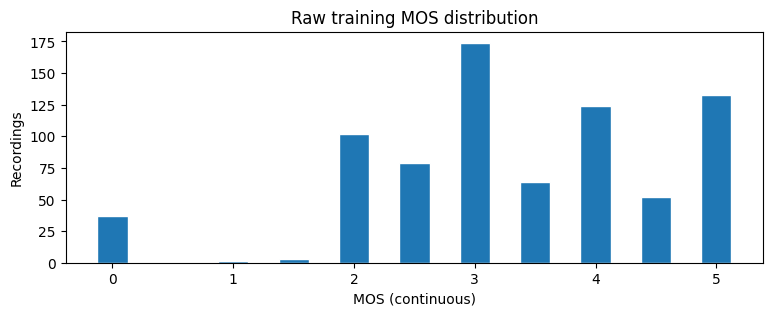

,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


In [3]:
def filename_column(df):
    names=['filename','file_name','audio_filename','audio_file','file','audio','path']
    cols={str(c).lower():c for c in df.columns}
    for k in names:
        if k in cols: return cols[k]
    raise ValueError(f'Filename column ambiguous: {list(df.columns)}')

def score_column(df, file_col):
    cols={str(c).lower():c for c in df.columns if c!=file_col}
    for k in ['label','score','mos','mos_score','grammar_score']:
        if k in cols: return cols[k]
    candidates=[c for c in df if c!=file_col and pd.api.types.is_numeric_dtype(df[c])]
    if len(candidates)==1: return candidates[0]
    raise ValueError(f'Set the target column explicitly: {candidates}')

def find_root():
    if CFG['DATA_ROOT'] is not None: return Path(CFG['DATA_ROOT'])
    candidates=[]
    for p in Path('/kaggle/input').rglob('train.csv'):
        root=p.parent
        if not (root/'test.csv').exists(): continue
        try:
            tr=pd.read_csv(p); te=pd.read_csv(root/'test.csv')
            filename_column(tr); filename_column(te)
            if len(tr)==769 and len(te)==216: candidates.append(root)
        except (ValueError, OSError): continue
    if len(candidates)!=1:
        raise ValueError(f'Expected one 769/216 SHL root; found {candidates}. Set DATA_ROOT in config.')
    return candidates[0]

ROOT=find_root()
train_df=pd.read_csv(ROOT/'train.csv'); test_df=pd.read_csv(ROOT/'test.csv')
sample_df=pd.read_csv(ROOT/'sample_submission.csv') if (ROOT/'sample_submission.csv').exists() else None
FILE_COL=filename_column(train_df); TEST_FILE_COL=filename_column(test_df)
LABEL_COL=score_column(train_df, FILE_COL)
y=pd.to_numeric(train_df[LABEL_COL], errors='raise').to_numpy(dtype=np.float32)
assert np.isfinite(y).all() and ((y>=0)&(y<=5)).all(), 'MOS must be finite in [0,5].'

def audio_key(value):
    name=Path(str(value).strip().replace('\\','/')).name.casefold()
    return name[:-4] if name.endswith('.wav') else name

def resolve_audio(frame, file_col, split):
    folder=ROOT/split
    if not folder.is_dir(): raise FileNotFoundError(folder)
    index={}
    for p in folder.rglob('*'):
        if p.suffix.lower()=='.wav': index.setdefault(audio_key(p.name), []).append(p)
    result=[]
    for value in frame[file_col].astype(str):
        rel=Path(value.replace('\\','/'))
        direct=folder/rel
        matches=[direct] if direct.is_file() and folder.resolve() in direct.resolve().parents else index.get(audio_key(value), [])
        if len(matches)!=1: raise ValueError(f'{split}: {value} resolves to {matches}; fix its path.')
        result.append(matches[0])
    keys=[audio_key(x) for x in frame[file_col]]
    if len(set(keys))!=len(keys): raise ValueError(f'{split}: duplicate normalized filename keys.')
    return result

train_paths=resolve_audio(train_df, FILE_COL, 'train')
test_paths=resolve_audio(test_df, TEST_FILE_COL, 'test')
paths=train_paths+test_paths

def file_sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for b in iter(lambda:f.read(1024*1024), b''): h.update(b)
    return h.hexdigest()

hashes=[file_sha(p) for p in tqdm(paths, desc='Hash audio / validate identities')]
TRAIN_N=len(train_df); TEST_N=len(test_df)
train_hashes=np.array(hashes[:TRAIN_N]); test_hashes=np.array(hashes[TRAIN_N:])
# Union metadata groups and exact duplicates; no inferred speaker threshold is treated as ground truth.
parent=np.arange(TRAIN_N)
def root_of(i):
    while parent[i]!=i:
        parent[i]=parent[parent[i]]; i=parent[i]
    return i

def union_matching(values):
    seen={}
    for i,v in enumerate(values):
        if pd.isna(v): continue
        if v in seen: parent[root_of(i)]=root_of(seen[v])
        else: seen[v]=i

union_matching(train_hashes)
group_col=CFG['GROUP_COLUMN']
if group_col is None:
    group_col=next((c for c in ['candidate_id','speaker_id','participant_id','person_id'] if c in train_df), None)
if group_col is not None:
    if group_col not in train_df: raise ValueError(f'Unknown GROUP_COLUMN: {group_col}')
    union_matching(train_df[group_col].to_numpy())
groups=np.array([root_of(i) for i in range(TRAIN_N)])
print('Root:', ROOT, '| train:', TRAIN_N, '| test:', TEST_N,
      '| sample:', None if sample_df is None else len(sample_df))
print('Grouping:', group_col or 'exact audio identities only', '| unique groups:', len(np.unique(groups)))
print('Repeated training content:', TRAIN_N-len(set(train_hashes)))
print('Exact content shared between train and test:', len(set(train_hashes)&set(test_hashes)))
if group_col is None:
    print('No real speaker/candidate IDs supplied: unseen-speaker accuracy remains unmeasured.')

ORIGINAL_SAMPLE_DF=None if sample_df is None else sample_df.copy()
ORIGINAL_SAMPLE_ROWS=None if sample_df is None else len(sample_df)
TEMPLATE_STATUS='absent' if sample_df is None else 'valid'
CFG['SUBMISSION_POLICY']='test'
if sample_df is not None:
    sc=filename_column(sample_df); scorecols=[c for c in sample_df if c!=sc]
    if len(scorecols)!=1: raise ValueError(f'Ambiguous template columns: {list(sample_df.columns)}')
    sk=[audio_key(v) for v in sample_df[sc]]; tk=[audio_key(v) for v in test_df[TEST_FILE_COL]]
    missing=sorted(set(sk)-set(tk)); duplicate_count=len(sk)-len(set(sk))
    if missing or duplicate_count:
        TEMPLATE_STATUS='incompatible IDs; schema reconstructed from test.csv'
        print('Template ID mismatch:',len(missing),'unknown IDs; examples:',missing[:10])
        print('Duplicate normalized template IDs:',duplicate_count)
        sample_df=pd.DataFrame({sc:test_df[TEST_FILE_COL].astype(str).to_numpy(),
                               scorecols[0]:np.zeros(TEST_N,dtype=np.float32)})[ORIGINAL_SAMPLE_DF.columns]
    elif len(sample_df)!=TEST_N: TEMPLATE_STATUS='valid subset of current test IDs'
    print('Original template rows:',ORIGINAL_SAMPLE_ROWS,'| status:',TEMPLATE_STATUS)
    ORIGINAL_SAMPLE_DF.to_csv(WORK/'original_sample_submission_v8.csv',index=False)
atomic_json(WORK/'data_integrity_v8.json',{'train_rows':TRAIN_N,'test_rows':TEST_N,
    'original_template_rows':ORIGINAL_SAMPLE_ROWS,'template_status':TEMPLATE_STATUS,
    'group_column':group_col,'unique_groups':int(len(np.unique(groups)))})
DATA_FINGERPRINT=stable_hash({'train':list(zip(train_df[FILE_COL].astype(str),train_hashes)),
                              'test':list(zip(test_df[TEST_FILE_COL].astype(str),test_hashes))})
fig,ax=plt.subplots(figsize=(9,3)); ax.hist(y, bins=np.arange(-.125,5.375,.25), edgecolor='white')
ax.set(title='Raw training MOS distribution', xlabel='MOS (continuous)', ylabel='Recordings'); plt.show()
display(train_df.head())


## 2. Full-recording features and restartable caches

Audio is converted to mono 16 kHz, with no arbitrary grammar correction, aggressive denoising, or deletion of pauses. Each full recording is covered by overlapping 15-second windows. WavLM contributes mean features from three depth levels and a final-layer standard deviation for each window. An independent speaker-verification encoder provides a style/identity signal; it is an ablation candidate, not a grammar label.

Whisper performs English **transcription**, not translation or prompted grammar correction. It may still normalize errors or hallucinate: raw waveform features, text features and audit diagnostics complement it. The complete transcript is tokenized before overlapping DeBERTa chunks are constructed. Chunk order and masks are preserved.

Per-file caches are keyed by audio content and extraction configuration, never row count alone. No label is included in a feature cache. An interrupted run keeps completed files. Runtime checkpoint files are inputs only to this same notebook's resume path.


In [4]:
# Resolve immutable weight versions so a changed Hub 'main' cannot reuse stale embeddings.
from huggingface_hub import model_info, snapshot_download
MODEL_COMMITS={}
model_sources=[CFG['AUDIO_MODEL'],CFG['ASR_MODEL'],CFG['TEXT_MODEL']]
if CFG['ENABLE_SPEAKER']: model_sources.append(CFG['SPEAKER_MODEL'])
if CFG['ENABLE_SECOND_ASR']: model_sources.append(CFG['CTC_MODEL'])
for source in model_sources:
    if Path(source).is_dir():
        # Local weights may be edited in place: fingerprint their contents, not just the path.
        files=sorted(p for p in Path(source).rglob('*') if p.is_file())
        MODEL_COMMITS[source]=stable_hash([(str(p.relative_to(source)),file_sha(p)) for p in files])
    else:
        supplied=CFG['MODEL_REVISIONS'].get(source)
        if supplied and re.fullmatch('[0-9a-f]{40}',supplied): MODEL_COMMITS[source]=supplied
        elif CFG['LOCAL_FILES_ONLY']:
            MODEL_COMMITS[source]=Path(snapshot_download(source,revision=supplied or 'main',local_files_only=True)).name
        else: MODEL_COMMITS[source]=model_info(source,revision=supplied or 'main').sha

def pretrained_args(source):
    opts={'local_files_only':CFG['LOCAL_FILES_ONLY']}
    if not Path(source).is_dir(): opts['revision']=MODEL_COMMITS[source]
    return opts

EXTRACT_CONFIG={k:CFG[k] for k in ['VERSION','AUDIO_MODEL','SPEAKER_MODEL','ASR_MODEL',
    'TEXT_MODEL','ENABLE_SPEAKER','AUDIO_SECONDS','AUDIO_STRIDE','MAX_AUDIO_CHUNKS',
    'TEXT_TOKENS','TEXT_OVERLAP','MAX_TEXT_CHUNKS']}
EXTRACT_CONFIG['transformers']=transformers.__version__
EXTRACT_CONFIG['weight_commits']=MODEL_COMMITS
EXTRACT_CONFIG['secondary_asr']={k:CFG[k] for k in ['ENABLE_SECOND_ASR','CTC_MODEL','CTC_CORE_SECONDS','CTC_CONTEXT_SECONDS']}
EXTRACT_CONFIG['feature_schema']='v8-with-dual-asr-v1'
FEATURE_KEY=stable_hash(EXTRACT_CONFIG)[:16]
FCACHE=CACHE/FEATURE_KEY; FCACHE.mkdir(exist_ok=True)
atomic_json(FCACHE/'feature_config.json', EXTRACT_CONFIG)

# Training does not see filenames, file numbers, CSV placeholder labels, or train/test indicators.
def load_audio(path):
    a,sr=sf.read(str(path), always_2d=True, dtype='float32')
    a=a.mean(axis=1)
    if len(a)==0 or not np.isfinite(a).all(): raise ValueError(f'Bad audio: {path}')
    if sr!=16000: a=librosa.resample(a, orig_sr=sr, target_sr=16000)
    return np.asarray(a, dtype=np.float32)

def audio_windows(a):
    length=int(16000*CFG['AUDIO_SECONDS']); stride=int(16000*CFG['AUDIO_STRIDE'])
    if len(a)<=length: return [np.pad(a,(0,max(0,16000-len(a))))]
    starts=list(range(0,len(a)-length+1,stride))
    if starts[-1]+length<len(a): starts.append(len(a)-length)
    if len(starts)>CFG['MAX_AUDIO_CHUNKS']:
        raise ValueError('Recording exceeds MAX_AUDIO_CHUNKS. Increase it; do not silently truncate.')
    return [a[s:s+length] for s in starts]

def acoustic_features(a):
    duration=len(a)/16000
    rms=librosa.feature.rms(y=a, frame_length=400, hop_length=160)[0]
    db=20*np.log10(np.maximum(rms,1e-8))
    active=db>max(-55, float(np.max(db))-30)
    padded=np.r_[True,active,True]; runs=np.diff(np.where(np.diff(padded.astype(int))!=0)[0])[::2]*.01
    zcr=librosa.feature.zero_crossing_rate(a, frame_length=400, hop_length=160)[0]
    centroid=librosa.feature.spectral_centroid(y=a,sr=16000,n_fft=512,hop_length=320)[0]
    bandwidth=librosa.feature.spectral_bandwidth(y=a,sr=16000,n_fft=512,hop_length=320)[0]
    mfcc=librosa.feature.mfcc(y=a,sr=16000,n_mfcc=13,n_fft=512,hop_length=320)
    v=[duration, np.log1p(np.sqrt(np.mean(a*a))), np.mean(np.abs(a)>.99),
       active.mean(), (runs>.2).sum()/max(duration,1), np.sum(runs[runs>.2])/max(duration,1)]
    for x in [db,zcr,centroid,bandwidth]:
        v.extend([np.mean(x),np.std(x),*np.quantile(x,[.1,.5,.9])])
    v.extend(mfcc.mean(axis=1)); v.extend(mfcc.std(axis=1))
    return np.nan_to_num(v, nan=0, posinf=0, neginf=0).astype(np.float32)

def feature_path(sha, branch): return FCACHE/f'{sha}_{branch}.npz'
def save_npz(path, **arrays):
    tmp=Path(str(path)+'.tmp')
    with open(tmp,'wb') as f: np.savez_compressed(f, **arrays)
    tmp.replace(path)

def cache_valid(path, required):
    if CFG['FORCE_REBUILD'] or not path.exists(): return False
    try:
        with np.load(path, allow_pickle=False) as z:
            return all(k in z and np.isfinite(z[k]).all() for k in required)
    except (ValueError,OSError,EOFError): return False


if CFG['REUSE_V7_FEATURES']:
    roots=[WORK/'v7_cache']
    if CFG['RESUME_DIR']: roots.append(Path(CFG['RESUME_DIR'])/'v7_cache')
    copied=0
    for old_root in roots:
        if not old_root.is_dir(): continue
        for meta_file in sorted(old_root.glob('*/feature_config.json')):
            old=json.loads(meta_file.read_text())
            common=[k for k in EXTRACT_CONFIG if k not in ['VERSION','weight_commits','secondary_asr','feature_schema']]
            if not all(old.get(k)==EXTRACT_CONFIG[k] for k in common): continue
            if any(old.get('weight_commits',{}).get(k)!=v for k,v in MODEL_COMMITS.items() if k!=CFG['CTC_MODEL']): continue
            for h in set(hashes):
                for suffix in ['audio.npz','speaker.npz','text.npz','transcript.json']:
                    src=meta_file.parent/f'{h}_{suffix}'; dst=FCACHE/src.name
                    if src.is_file() and not dst.exists(): shutil.copy2(src,dst); copied+=1
    print('Matching V7 unsupervised cache files reused:',copied)

audio_pending=any(not cache_valid(feature_path(h,'audio'),['chunks','acoustic']) for h in hashes)
if audio_pending:
    af=AutoFeatureExtractor.from_pretrained(CFG['AUDIO_MODEL'], **pretrained_args(CFG['AUDIO_MODEL']))
    am=AutoModel.from_pretrained(CFG['AUDIO_MODEL'], **pretrained_args(CFG['AUDIO_MODEL'])).to(DEVICE).eval()
    for p,h in tqdm(list(zip(paths,hashes)),desc='Full-recording multi-layer WavLM'):
        dest=feature_path(h,'audio')
        if cache_valid(dest,['chunks','acoustic']): continue
        a=load_audio(p); vectors=[]
        with torch.inference_mode():
            for w in audio_windows(a):
                inp=af(w,sampling_rate=16000,return_tensors='pt')['input_values'].to(DEVICE)
                with amp_context(): out=am(input_values=inp,output_hidden_states=True)
                # Mean at 3 layer depths + last-layer standard deviation; no padded frames.
                means=[out.hidden_states[k][0].float().mean(0) for k in [-7,-4,-1]]
                std=out.hidden_states[-1][0].float().std(0,unbiased=False)
                vectors.append(torch.cat(means+[std]).cpu().numpy())
        save_npz(dest,chunks=np.stack(vectors).astype('float32'),acoustic=acoustic_features(a))
    del am,af; release()

if CFG['ENABLE_SPEAKER']:
    pending=any(not cache_valid(feature_path(h,'speaker'),['speaker']) for h in hashes)
    if pending:
        spf=AutoFeatureExtractor.from_pretrained(CFG['SPEAKER_MODEL'], **pretrained_args(CFG['SPEAKER_MODEL']))
        spm=AutoModelForAudioXVector.from_pretrained(CFG['SPEAKER_MODEL'], **pretrained_args(CFG['SPEAKER_MODEL'])).to(DEVICE).eval()
        for p,h in tqdm(list(zip(paths,hashes)),desc='Speaker verification embeddings'):
            dest=feature_path(h,'speaker')
            if cache_valid(dest,['speaker']): continue
            a=load_audio(p); vs=[]
            # Up to three nonoverlapping long windows span the full recording.
            for w in np.array_split(a,max(1,int(np.ceil(len(a)/(20*16000))))):
                if len(w)<16000: w=np.pad(w,(0,16000-len(w)))
                inp=spf(w,sampling_rate=16000,return_tensors='pt')['input_values'].to(DEVICE)
                with torch.inference_mode(), amp_context(): v=spm(input_values=inp).embeddings[0]
                vs.append(v.float().cpu().numpy())
            v=np.mean(vs,axis=0); v=v/max(np.linalg.norm(v),1e-8)
            save_npz(dest,speaker=v.astype('float32'))
        del spf,spm; release()
print('Audio and speaker caches ready:', FEATURE_KEY)


Matching V7 unsupervised cache files reused: 0


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/405M [00:00<?, ?B/s]

Speaker verification embeddings:   0%|          | 0/985 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/404M [00:00<?, ?B/s]

Audio and speaker caches ready: 8f156ae3551657ca


In [5]:
# Long-form Whisper generation: truncation=False and return_timestamps=True
# are necessary so a 45–60 second file is not reduced to its first 30 seconds.
def transcript_path(h): return FCACHE/f'{h}_transcript.json'
def transcript_valid(path):
    if CFG['FORCE_REBUILD'] or not path.exists(): return False
    try:
        obj=json.loads(path.read_text()); return isinstance(obj['text'],str) and 'segments' in obj
    except (ValueError,KeyError,OSError): return False

if any(not transcript_valid(transcript_path(h)) for h in hashes):
    proc=AutoProcessor.from_pretrained(CFG['ASR_MODEL'], **pretrained_args(CFG['ASR_MODEL']))
    dtype=torch.float16 if DEVICE.type=='cuda' else torch.float32
    asr=AutoModelForSpeechSeq2Seq.from_pretrained(CFG['ASR_MODEL'], torch_dtype=dtype,
        low_cpu_mem_usage=True, **pretrained_args(CFG['ASR_MODEL'])).to(DEVICE).eval()
    for p,h in tqdm(list(zip(paths,hashes)),desc='Whisper complete recordings'):
        dest=transcript_path(h)
        if transcript_valid(dest): continue
        a=load_audio(p)
        batch=proc(a,sampling_rate=16000,return_tensors='pt',
                   truncation=False,padding='longest',return_attention_mask=True)
        inputs=batch['input_features'].to(DEVICE,dtype=dtype)
        mask=batch['attention_mask'].to(DEVICE)
        with torch.inference_mode():
            result=asr.generate(input_features=inputs,attention_mask=mask,
                language='english',task='transcribe',return_timestamps=True,
                return_segments=True,num_beams=1,do_sample=False,temperature=0.0,
                condition_on_prev_tokens=False,compression_ratio_threshold=2.4,
                logprob_threshold=-1.0,no_speech_threshold=0.6)
        # Long-form generation with return_segments=True returns a dictionary.
        sequences=result['sequences'] if isinstance(result,dict) else result
        text=proc.batch_decode(sequences,skip_special_tokens=True)[0].strip()
        segments=[]
        if isinstance(result,dict):
            raw_segments=result.get('segments',[])
            raw_segments=raw_segments[0] if len(raw_segments) else []
            for s in raw_segments:
                st=float(s['start']); en=float(s['end'])
                segments.append({'start':st,'end':en,
                    'text':proc.decode(s['tokens'],skip_special_tokens=True).strip()})
        atomic_json(dest,{'text':text,'segments':segments,'duration':len(a)/16000})
    del asr,proc; release()

transcripts=[json.loads(transcript_path(h).read_text()) for h in hashes]
text_list=[t['text'] for t in transcripts]
transcript_df=pd.DataFrame({'split':['train']*TRAIN_N+['test']*TEST_N,
    'filename':train_df[FILE_COL].astype(str).tolist()+test_df[TEST_FILE_COL].astype(str).tolist(),
    'transcript':text_list,'duration':[t['duration'] for t in transcripts]})
transcript_df.to_csv(WORK/'transcripts_primary_v8.csv',index=False)
print('Empty transcripts:',sum(not t.strip() for t in text_list))
display(transcript_df[['split','filename','transcript']].head(5))


preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

Whisper complete recordings:   0%|          | 0/985 [00:00<?, ?it/s]

Empty transcripts: 0


,split,filename,transcript
0,train,audio_192.wav,The playground is very beautiful and fun. Ther...
1,train,audio_436.wav,the scene of a school playground our playgroun...
2,train,audio_447.wav,My favorite place to visit is the beach. I lov...
3,train,audio_126.wav,Once upon a time we with 5 friends went on a t...
4,train,audio_61.wav,"Well, when I was a child, I remember I went to..."


## V8 secondary ASR and quality features
The CTC recognizer uses 20-second core regions with two-second context on both sides. Frame predictions are trimmed back to the cores before joining, so overlapping speech is not duplicated. It produces a second transcription, not a corrected version of Whisper text. ASR confidence, entropy, blank rate, lexical disagreement and CTC hidden-state statistics are label-free features. Uncertain ASR remains a limitation rather than an invented grammar target.


In [6]:
def ctc_path(h): return FCACHE/f'{h}_ctc.npz'
if CFG['ENABLE_SECOND_ASR']:
    if any(not cache_valid(ctc_path(h),['quality','embedding']) for h in hashes):
        cp=AutoProcessor.from_pretrained(CFG['CTC_MODEL'],**pretrained_args(CFG['CTC_MODEL']))
        cm=AutoModelForCTC.from_pretrained(CFG['CTC_MODEL'],**pretrained_args(CFG['CTC_MODEL'])).to(DEVICE).eval()
        for path,h in tqdm(list(zip(paths,hashes)),desc='CTC second transcription view'):
            dst=ctc_path(h)
            if cache_valid(dst,['quality','embedding']): continue
            a=load_audio(path); core=int(CFG['CTC_CORE_SECONDS']*16000); context=int(CFG['CTC_CONTEXT_SECONDS']*16000)
            token_parts=[]; confidence=[]; entropy=[]; blank=[]; hidden_sums=[]; frames=[]
            for start in range(0,len(a),core):
                stop=min(start+core,len(a)); left=max(0,start-context); right=min(len(a),stop+context)
                w=a[left:right]
                if len(w)<16000: w=np.pad(w,(0,16000-len(w)))
                batch=cp(w,sampling_rate=16000,return_tensors='pt')
                batch={k:v.to(DEVICE) for k,v in batch.items() if k in ['input_values','attention_mask']}
                with torch.inference_mode(),amp_context(): out=cm(**batch,output_hidden_states=True)
                logits=out.logits[0].float(); length=len(logits)
                lo=int(round((start-left)/len(w)*length)); hi=int(round((stop-left)/len(w)*length))
                hi=max(lo+1,min(hi,length)); logits=logits[lo:hi]
                prob=logits.softmax(-1); ids=prob.argmax(-1)
                token_parts.append(ids.cpu().numpy())
                confidence.append(prob.max(-1).values.cpu().numpy())
                entropy.append((-(prob*prob.clamp_min(1e-8).log()).sum(-1)/math.log(prob.shape[-1])).cpu().numpy())
                blank.append((ids==cm.config.pad_token_id).float().cpu().numpy())
                hidden=out.hidden_states[-1][0,lo:hi].float()
                hidden_sums.append(hidden.sum(0).cpu().numpy()); frames.append(len(hidden))
            token_ids=np.concatenate(token_parts)
            text=cp.batch_decode([token_ids.tolist()])[0].strip()
            conf=np.concatenate(confidence); ent=np.concatenate(entropy); blanks=np.concatenate(blank)
            qual=np.array([conf.mean(),conf.std(),np.quantile(conf,.1),ent.mean(),ent.std(),blanks.mean()],dtype='float32')
            embedding=np.sum(hidden_sums,axis=0)/max(1,sum(frames))
            save_npz(dst,text=np.array(text),quality=qual,embedding=embedding.astype('float32'))
        del cp,cm; release()
    ALT_TEXT_LIST=[]; CTC_QUALITY=[]; CTC_AUDIO=[]
    for h in hashes:
        with np.load(ctc_path(h),allow_pickle=False) as z:
            ALT_TEXT_LIST.append(str(z['text'].item()))
            CTC_QUALITY.append(z['quality']); CTC_AUDIO.append(z['embedding'])
    CTC_QUALITY=np.stack(CTC_QUALITY); CTC_AUDIO=np.stack(CTC_AUDIO)
else:
    ALT_TEXT_LIST=list(text_list); CTC_QUALITY=np.zeros((len(paths),6),dtype='float32'); CTC_AUDIO=np.zeros((len(paths),1),dtype='float32')
transcript_df['ctc_transcript']=ALT_TEXT_LIST
transcript_df['asr_word_agreement']=[difflib.SequenceMatcher(None,a.lower().split(),b.lower().split(),autojunk=False).ratio() for a,b in zip(text_list,ALT_TEXT_LIST)]
transcript_df.to_csv(WORK/'transcripts_generated_v8.csv',index=False)
print('Second ASR enabled:',CFG['ENABLE_SECOND_ASR'],'| mean word agreement:',transcript_df.asr_word_agreement.mean())


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h-lv60-self and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CTC second transcription view:   0%|          | 0/985 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Second ASR enabled: True | mean word agreement: 0.7291785182906434


In [7]:
tokenizer=AutoTokenizer.from_pretrained(CFG['TEXT_MODEL'],use_fast=False,**pretrained_args(CFG['TEXT_MODEL']))

def text_chunks(text):
    ids=tokenizer.encode(text,add_special_tokens=False,truncation=False)
    content_length=CFG['TEXT_TOKENS']-tokenizer.num_special_tokens_to_add(pair=False)
    stride=content_length-CFG['TEXT_OVERLAP']
    chunks=[]
    for start in range(0,max(1,len(ids)),stride):
        pieces=ids[start:start+content_length]
        chunks.append(tokenizer.build_inputs_with_special_tokens(pieces))
        if start+content_length>=len(ids): break
    if len(chunks)>CFG['MAX_TEXT_CHUNKS']:
        raise ValueError('Transcript exceeds MAX_TEXT_CHUNKS. Increase it; no hidden token truncation.')
    return chunks

TOKEN_CHUNKS=[text_chunks(t) for t in text_list]
if any(not cache_valid(feature_path(h,'text'),['chunks']) for h in hashes):
    tm=AutoModel.from_pretrained(CFG['TEXT_MODEL'], **pretrained_args(CFG['TEXT_MODEL'])).to(DEVICE).eval()
    for i,h in tqdm(list(enumerate(hashes)),desc='Ordered DeBERTa transcript embeddings'):
        dest=feature_path(h,'text')
        if cache_valid(dest,['chunks']): continue
        vs=[]
        for chunk in TOKEN_CHUNKS[i]:
            inp=tokenizer.pad({'input_ids':[chunk]},padding=True,return_tensors='pt')
            inp={k:v.to(DEVICE) for k,v in inp.items() if k in ['input_ids','attention_mask']}
            with torch.inference_mode(), amp_context(): hidden=tm(**inp).last_hidden_state
            mask=inp['attention_mask'].unsqueeze(-1)
            v=(hidden.float()*mask).sum(1)/mask.sum(1).clamp_min(1)
            vs.append(v[0].cpu().numpy())
        save_npz(dest,chunks=np.stack(vs).astype('float32'))
    del tm; release()

def linguistic_features(t):
    text=t['text']; words=re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?",text.lower())
    n=len(words); counts=Counter(words); duration=max(t['duration'],1)
    sentences=[s for s in re.split(r'[.!?]+',text) if s.strip()]
    sent_lens=[len(re.findall(r'[A-Za-z]+',s)) for s in sentences] or [0]
    adjacent=sum(a==b for a,b in zip(words,words[1:]))
    filler=sum(counts[w] for w in ['um','uh','erm','hmm'])
    connectives=sum(counts[w] for w in ['although','because','however','therefore','unless','while','which','if'])
    gaps=[max(0,b['start']-a['end']) for a,b in zip(t['segments'],t['segments'][1:])]
    return np.array([n,n/duration,len(counts)/max(n,1),
        sum(v==1 for v in counts.values())/max(n,1),np.mean([len(w) for w in words]) if n else 0,
        len(sentences),np.mean(sent_lens),np.std(sent_lens),filler/max(n,1),
        adjacent/max(n,1),connectives/max(n,1),int(n==0),
        np.mean(gaps) if gaps else 0,np.max(gaps) if gaps else 0],dtype='float32')

AUDIO_DIM=np.load(feature_path(hashes[0],'audio'))['chunks'].shape[1]
TEXT_DIM=np.load(feature_path(hashes[0],'text'))['chunks'].shape[1]
N=len(paths)
A=np.zeros((N,CFG['MAX_AUDIO_CHUNKS'],AUDIO_DIM),dtype='float32'); AM=np.zeros(A.shape[:2],dtype=bool)
T=np.zeros((N,CFG['MAX_TEXT_CHUNKS'],TEXT_DIM),dtype='float32'); TM=np.zeros(T.shape[:2],dtype=bool)
dense=[]; speakers=[]
for i,h in enumerate(hashes):
    with np.load(feature_path(h,'audio')) as z:
        c=z['chunks']; A[i,:len(c)]=c; AM[i,:len(c)]=True
        dense.append(np.r_[z['acoustic'],linguistic_features(transcripts[i])])
    with np.load(feature_path(h,'text')) as z:
        c=z['chunks']; T[i,:len(c)]=c; TM[i,:len(c)]=True
    if CFG['ENABLE_SPEAKER']:
        with np.load(feature_path(h,'speaker')) as z: speakers.append(z['speaker'])
D=np.stack(dense).astype('float32')
SP=np.stack(speakers).astype('float32') if speakers else np.zeros((N,1),dtype='float32')
FEATURES=dict(audio=A,amask=AM,text=T,tmask=TM,dense=D,speaker=SP)
assert all(np.isfinite(v).all() for v in FEATURES.values())
assert AM.any(1).all() and TM.any(1).all()
np.savez_compressed(WORK/'features_base_v8.npz',**FEATURES)
print({k:v.shape for k,v in FEATURES.items()})
atomic_json(WORK/'feature_manifest_base_v8.json',{'dataset_fingerprint':DATA_FINGERPRINT,
    'feature_key':FEATURE_KEY,'ordered_filenames':transcript_df.filename.tolist(),
    'hashes':hashes,'configuration':EXTRACT_CONFIG})


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Ordered DeBERTa transcript embeddings:   0%|          | 0/985 [00:00<?, ?it/s]

{'audio': (985, 8, 3072), 'amask': (985, 8), 'text': (985, 8, 768), 'tmask': (985, 8), 'dense': (985, 66), 'speaker': (985, 512)}


## 3. Fold-local preprocessing and grammar objectives
All raw labels stay continuous. Fold scalers exclude padded chunks and are fitted on training partitions only.
Residual and ordinal heads preserve the V7 model families. Soft ordinal targets interpolate between adjacent 0.25 anchors;
MSE remains primary, a CDF objective preserves distances, and ranking is a small auxiliary term. Uniform sampling avoids
changing the target prior through score oversampling. Zero classification is auxiliary only when zero labels exist.
V8 additionally trains a cross-modal transformer and the supervised hierarchical audio/text encoders below.


In [8]:
TOKEN_CHUNKS_ALT=[text_chunks(t) for t in ALT_TEXT_LIST]
def alt_path(h): return FCACHE/f'{h}_alt_text.npz'
if CFG['ENABLE_SECOND_ASR']:
    if any(not cache_valid(alt_path(h),['chunks']) for h in hashes):
        tm=AutoModel.from_pretrained(CFG['TEXT_MODEL'],**pretrained_args(CFG['TEXT_MODEL'])).to(DEVICE).eval()
        for i,h in tqdm(list(enumerate(hashes)),desc='Second-view DeBERTa embeddings'):
            dst=alt_path(h)
            if cache_valid(dst,['chunks']): continue
            vs=[]
            for chunk in TOKEN_CHUNKS_ALT[i]:
                inp=tokenizer.pad({'input_ids':[chunk]},padding=True,return_tensors='pt')
                inp={k:v.to(DEVICE) for k,v in inp.items() if k in ['input_ids','attention_mask']}
                with torch.inference_mode(),amp_context(): hidden=tm(**inp).last_hidden_state
                mask=inp['attention_mask'][...,None]
                v=(hidden.float()*mask).sum(1)/mask.sum(1).clamp_min(1)
                vs.append(v[0].cpu().numpy())
            save_npz(dst,chunks=np.stack(vs).astype('float32'))
        del tm; release()
    ALT=np.zeros_like(T); ALTM=np.zeros_like(TM)
    for i,h in enumerate(hashes):
        with np.load(alt_path(h)) as z:
            c=z['chunks']; ALT[i,:len(c)]=c; ALTM[i,:len(c)]=True
else: ALT=T.copy(); ALTM=TM.copy()
# Label-free ASR and secondary speech representations; fitted scaling remains fold-local.
BASE_DENSE_DIM=D.shape[1]
agreement=transcript_df.asr_word_agreement.to_numpy(dtype='float32')[:,None]
word_counts=np.array([[len(a.split()),len(b.split())] for a,b in zip(text_list,ALT_TEXT_LIST)],dtype='float32')
D=np.c_[D,CTC_QUALITY,agreement,np.log1p(word_counts),CTC_AUDIO].astype('float32')
FEATURES.update(alt_text=ALT,altmask=ALTM,dense=D)
np.savez_compressed(WORK/'features_v8.npz',**FEATURES)
atomic_json(WORK/'feature_manifest_v8.json',{'dataset_fingerprint':DATA_FINGERPRINT,
    'feature_key':FEATURE_KEY,'ordered_filenames':transcript_df.filename.tolist(),
    'hashes':hashes,'configuration':EXTRACT_CONFIG,'base_dense_dim':BASE_DENSE_DIM})
print('V8 feature shapes:',{k:v.shape for k,v in FEATURES.items()})


Second-view DeBERTa embeddings:   0%|          | 0/985 [00:00<?, ?it/s]

V8 feature shapes: {'audio': (985, 8, 3072), 'amask': (985, 8), 'text': (985, 8, 768), 'tmask': (985, 8), 'dense': (985, 1099), 'speaker': (985, 512), 'alt_text': (985, 8, 768), 'altmask': (985, 8)}


In [9]:
def masked_mean(x, mask):
    return (x*mask[...,None]).sum(1)/np.maximum(mask.sum(1,keepdims=True),1)

def slice_features(ids): return {k:v[ids] for k,v in FEATURES.items()}

class FoldScaler:
    def fit(self,f):
        self.audio=StandardScaler().fit(f['audio'][f['amask']])
        self.text=StandardScaler().fit(f['text'][f['tmask']])
        self.alt=StandardScaler().fit(f['alt_text'][f['altmask']])
        self.dense=StandardScaler().fit(f['dense'])
        return self
    def transform(self,f):
        out={k:v.copy() for k,v in f.items()}
        for key,mask,sc in [('audio','amask',self.audio),('text','tmask',self.text),('alt_text','altmask',self.alt)]:
            out[key][out[mask]]=np.clip(sc.transform(out[key][out[mask]]),-8,8)
            out[key][~out[mask]]=0
        out['dense']=np.clip(self.dense.transform(out['dense']),-8,8).astype('float32')
        return out

def dense_matrix(f, mode='fusion'):
    a=masked_mean(f['audio'],f['amask']); t=masked_mean(f['text'],f['tmask'])
    blocks={'audio':[a], 'text':[t], 'fusion':[a,t,f['dense']],
            'speaker':[a,t,f['dense'],f['speaker']],
            'dual_text':[t,masked_mean(f['alt_text'],f['altmask']),f['dense']]}[mode]
    return np.concatenate([x/np.sqrt(max(1,x.shape[1])) for x in blocks],axis=1).astype('float32')

class ResidualBlock(nn.Module):
    def __init__(self,width):
        super().__init__(); self.net=nn.Sequential(nn.LayerNorm(width),nn.Linear(width,width),
            nn.GELU(),nn.Dropout(.2),nn.Linear(width,width))
    def forward(self,x): return x+self.net(x)

class FusionHead(nn.Module):
    def __init__(self,ad,td,dd,kind,mean):
        super().__init__(); self.kind=kind
        self.register_buffer('anchors',torch.linspace(0,5,21))
        self.ap=nn.Sequential(nn.Linear(ad,96),nn.LayerNorm(96),nn.GELU())
        self.tp=nn.Sequential(nn.Linear(td,96),nn.LayerNorm(96),nn.GELU())
        self.dp=nn.Sequential(nn.Linear(dd,32),nn.LayerNorm(32),nn.GELU())
        self.apos=nn.Parameter(torch.zeros(1,CFG['MAX_AUDIO_CHUNKS'],96))
        self.tpos=nn.Parameter(torch.zeros(1,CFG['MAX_TEXT_CHUNKS'],96))
        self.aa=nn.Linear(96,1); self.ta=nn.Linear(96,1)
        self.body=nn.Sequential(nn.Linear(224,128),nn.GELU(),nn.Dropout(.25),ResidualBlock(128),nn.LayerNorm(128))
        self.output=nn.Linear(128,21 if kind=='ordinal' else 1)
        self.skip=nn.Linear(224,1)
        self.zero=nn.Linear(128,1)
        if kind!='ordinal':
            nn.init.zeros_(self.output.weight); nn.init.constant_(self.output.bias,mean)
            nn.init.zeros_(self.skip.weight); nn.init.zeros_(self.skip.bias)
    def pool(self,x,mask,projection,pos,attention):
        z=projection(x)
        if self.kind=='attention_rank':
            z=z+pos[:,:x.shape[1]]
            scores=attention(torch.tanh(z)).squeeze(-1).masked_fill(~mask,-1e4)
            return (z*scores.softmax(1)[...,None]).sum(1)
        return (z*mask[...,None]).sum(1)/mask.sum(1,keepdim=True).clamp_min(1)
    def forward(self,a,am,t,tm,d,alt=None,altmask=None):
        av=self.pool(a,am,self.ap,self.apos,self.aa)
        tv=self.pool(t,tm,self.tp,self.tpos,self.ta)
        z=torch.cat([av,tv,self.dp(d)],dim=1); h=self.body(z)
        raw=self.output(h); probs=None
        if self.kind=='ordinal':
            probs=raw.softmax(-1); score=(probs*self.anchors).sum(-1)
        else: score=raw.squeeze(-1)+self.skip(z).squeeze(-1)
        return score,raw,probs,self.zero(h).squeeze(-1)

def soft_ordinal(yb):
    z=(yb/0.25).clamp(0,20); lo=z.floor().long(); hi=(lo+1).clamp(max=20); fraction=z-lo
    target=torch.zeros(len(yb),21,device=yb.device)
    target.scatter_add_(1,lo[:,None],(1-fraction)[:,None])
    target.scatter_add_(1,hi[:,None],fraction[:,None])
    return target

def rank_loss(p,yb):
    diff=yb[:,None]-yb[None,:]
    mask=torch.triu(torch.ones_like(diff,dtype=torch.bool),diagonal=1)&(diff.abs()>=0.5)
    if not mask.any(): return p.sum()*0
    pdiff=p[:,None]-p[None,:]
    return TF.softplus(-diff[mask].sign()*pdiff[mask]).mean()

def head_loss(output,yb,kind,has_zero):
    score,raw,probs,zero=output
    loss=TF.mse_loss(score,yb)
    if kind=='ordinal':
        target=soft_ordinal(yb)
        loss=loss+.2*(-target*TF.log_softmax(raw,-1)).sum(-1).mean()
        loss=loss+.2*TF.mse_loss(probs.cumsum(-1),target.cumsum(-1))
    if kind=='attention_rank': loss=loss+.05*rank_loss(score,yb)
    if has_zero: loss=loss+.05*TF.binary_cross_entropy_with_logits(zero,(yb==0).float())
    return loss

def feature_dataset(f,labels=None):
    fields=[f['audio'],f['amask'],f['text'],f['tmask'],f['dense'],f['alt_text'],f['altmask']]
    tensors=[torch.as_tensor(x) for x in fields]
    if labels is not None: tensors.append(torch.as_tensor(labels,dtype=torch.float32))
    return TensorDataset(*tensors)

@torch.inference_mode()
def predict_head(model,f):
    model.eval(); pred=[]
    for batch in DataLoader(feature_dataset(f),batch_size=128,shuffle=False):
        batch=[x.to(DEVICE) for x in batch]
        pred.append(model(*batch)[0].float().cpu().numpy())
    return clip(np.concatenate(pred))

def new_head(kind,f,labels):
    return FusionHead(f['audio'].shape[-1],f['text'].shape[-1],f['dense'].shape[-1],kind,float(np.mean(labels))).to(DEVICE)

def train_head(kind,f,labels,seed,valid=None,epochs=None):
    seed_all(seed); model=new_head(kind,f,labels)
    opt=torch.optim.AdamW(model.parameters(),lr=CFG['HEAD_LR'],weight_decay=CFG['HEAD_WEIGHT_DECAY'])
    total=epochs or CFG['HEAD_EPOCHS']; best=np.inf; best_epoch=1; wait=0; best_state=None
    generator=torch.Generator().manual_seed(seed)
    loader=DataLoader(feature_dataset(f,labels),batch_size=CFG['HEAD_BATCH'],shuffle=True,generator=generator)
    for epoch in range(1,total+1):
        model.train()
        for *batch,yb in loader:
            batch=[x.to(DEVICE) for x in batch]; yb=yb.to(DEVICE)
            # Modest feature noise only on valid windows; padded positions stay zero.
            batch[0]=batch[0]+.01*torch.randn_like(batch[0])*batch[1][...,None]
            batch[2]=batch[2]+.01*torch.randn_like(batch[2])*batch[3][...,None]
            loss=head_loss(model(*batch),yb,kind,bool(np.any(labels==0)))
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        if valid is not None:
            vf,vy=valid; error=metrics(vy,predict_head(model,vf))['rmse']
            if error<best-1e-4:
                best=error; best_epoch=epoch; wait=0
                best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            else: wait+=1
            if wait>=CFG['HEAD_PATIENCE']: break
    if valid is not None:
        model.load_state_dict(best_state); return model,best_epoch
    return model,total


In [10]:
# Group-aware split helpers. No label-valued file identifiers or inferred speaker labels.
def cv_splits(ids,nfold,seed):
    ids=np.asarray(ids); bins=np.floor(np.clip(y[ids],0,4.999)).astype(int)
    if len(np.unique(groups[ids]))<nfold: raise ValueError('Too few distinct groups for CV.')
    if len(np.unique(groups[ids]))<len(ids):
        splitter=StratifiedGroupKFold(n_splits=nfold,shuffle=True,random_state=seed)
        splits=splitter.split(ids,bins,groups[ids])
    elif len(np.unique(bins))>1 and pd.Series(bins).value_counts().min()>=nfold:
        splits=StratifiedKFold(n_splits=nfold,shuffle=True,random_state=seed).split(ids,bins)
    else: splits=KFold(n_splits=nfold,shuffle=True,random_state=seed).split(ids)
    return [(ids[a],ids[b]) for a,b in splits]

def internal_split(ids,seed,size=.18):
    ids=np.asarray(ids)
    if len(np.unique(groups[ids]))<len(ids):
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=size,random_state=seed).split(ids,groups=groups[ids]))
        return ids[a],ids[b]
    bins=np.floor(np.clip(y[ids],0,4.999)).astype(int)
    counts=pd.Series(bins).value_counts()
    strat=bins if counts.min()>=2 and int(np.ceil(len(ids)*size))>=len(counts) and int(len(ids)*(1-size))>=len(counts) else None
    a,b=train_test_split(ids,test_size=size,random_state=seed,stratify=strat)
    return np.asarray(a),np.asarray(b)


## 4. Training-only tuning, retrieval and checkpoints
Ridge and RBF hyperparameters and CatBoost iteration counts are selected on an internal split of each outer training fold.
Scalers for this tuning split are independently fitted. The final outer model is then refitted on its complete training
partition. Speaker retrieval uses training labels only, excludes exact duplicate query audio, and has a fixed confidence gate.
No filename numbers or test labels are predictive features. Learner checkpoints permit epoch-level resume; completed fold
prediction arrays permit immediate inference resume. Cache keys include code/configuration, labels, identities and versions.


## Supervised audio and text learning, with resumable optimization
Audio training samples two recording windows per epoch while inference covers every window. Sampling does not assign independent labels to windows: predictions are aggregated to a recording-level MOS loss. The audio convolutional front end stays frozen; the last transformer blocks learn SHL-specific patterns. Text training can choose the alternate ASR view; primary and combined-view inference are separate ensemble candidates.

The optimizers use separate encoder/head learning rates, a head-only warmup epoch, warmup/cosine learning-rate scheduling, gradient accumulation, mixed precision and clipping. EMA weights are used consistently for internal validation and inference. Internal validation chooses epochs; each outer training fold is then refitted from the pretrained initialization using that epoch count. No outer validation or audit target selects epochs. Warmup and EMA are training choices, not guarantees of improvement.


In [11]:
class CrossModalTransformer(nn.Module):
    def __init__(self,f,mean):
        super().__init__(); self.kind='cross_modal'
        self.ap=nn.Linear(f['audio'].shape[-1],96); self.tp=nn.Linear(f['text'].shape[-1],96)
        self.altp=nn.Linear(f['alt_text'].shape[-1],96); self.dp=nn.Linear(f['dense'].shape[-1],96)
        max_tokens=2+CFG['MAX_AUDIO_CHUNKS']+2*CFG['MAX_TEXT_CHUNKS']
        self.positions=nn.Parameter(torch.zeros(1,max_tokens,96))
        self.modality=nn.Parameter(torch.randn(4,96)*.02); self.cls=nn.Parameter(torch.zeros(1,1,96))
        layer=nn.TransformerEncoderLayer(96,4,dim_feedforward=256,dropout=.15,batch_first=True,norm_first=True)
        self.encoder=nn.TransformerEncoder(layer,num_layers=2,enable_nested_tensor=False)
        self.norm=nn.LayerNorm(96); self.score=nn.Linear(96,1); self.ordinal=nn.Linear(96,21); self.zero=nn.Linear(96,1)
        self.register_buffer('anchors',torch.linspace(0,5,21)); nn.init.constant_(self.score.bias,mean)
    def forward(self,a,am,t,tm,d,alt,altmask):
        b=len(a)
        seq=torch.cat([self.cls.expand(b,-1,-1),self.ap(a)+self.modality[0],
            self.tp(t)+self.modality[1],self.altp(alt)+self.modality[2],
            (self.dp(d)+self.modality[3])[:,None]],1)
        mask=torch.cat([torch.ones(b,1,dtype=torch.bool,device=a.device),am,tm,altmask,
                        torch.ones(b,1,dtype=torch.bool,device=a.device)],1)
        h=self.encoder(seq+self.positions[:,:seq.shape[1]],src_key_padding_mask=~mask)
        pooled=self.norm(h[:,0]); logits=self.ordinal(pooled); probs=logits.softmax(-1)
        score=.85*self.score(pooled).squeeze(-1)+.15*(probs*self.anchors).sum(-1)
        return score,logits,probs,self.zero(pooled).squeeze(-1)

class TextMOSLearner(nn.Module):
    def __init__(self,dense_dim,mean):
        super().__init__(); self.kind='text_supervised'
        self.encoder=AutoModel.from_pretrained(CFG['TEXT_MODEL'],**pretrained_args(CFG['TEXT_MODEL']))
        for p in self.encoder.parameters(): p.requires_grad=False
        for layer in self.encoder.encoder.layer[-CFG['FT_UNFREEZE']:]:
            for p in layer.parameters(): p.requires_grad=True
        hd=self.encoder.config.hidden_size; self.mix=nn.Parameter(torch.zeros(min(4,len(self.encoder.encoder.layer))))
        self.token_att=nn.Linear(hd,1); self.project=nn.Linear(hd,128)
        self.positions=nn.Parameter(torch.zeros(1,CFG['MAX_TEXT_CHUNKS'],128))
        self.chunk_att=nn.Linear(128,1)
        layer=nn.TransformerEncoderLayer(128,4,256,.15,batch_first=True,norm_first=True)
        self.context=nn.TransformerEncoder(layer,1,enable_nested_tensor=False)
        self.dp=nn.Sequential(nn.Linear(dense_dim,32),nn.GELU())
        self.body=nn.Sequential(nn.Linear(160,128),nn.GELU(),nn.Dropout(.2),nn.LayerNorm(128))
        self.score=nn.Linear(128,1); self.ordinal=nn.Linear(128,21); self.zero=nn.Linear(128,1)
        self.register_buffer('anchors',torch.linspace(0,5,21)); nn.init.constant_(self.score.bias,mean)
    def forward(self,ids,mask,chunkmask,dense):
        b,c,l=ids.shape; selected=chunkmask.flatten()
        ii=ids.reshape(b*c,l)[selected]; mm=mask.reshape(b*c,l)[selected]
        out=self.encoder(input_ids=ii,attention_mask=mm,output_hidden_states=True)
        stacked=torch.stack(out.hidden_states[-len(self.mix):],0)
        h=(stacked*self.mix.softmax(0)[:,None,None,None]).sum(0)
        score=self.token_att(torch.tanh(h)).squeeze(-1).masked_fill(~mm.bool(),-1e4)
        v=(h*score.softmax(1)[...,None]).sum(1); v=self.project(v)
        full=v.new_zeros(b*c,128); full[selected]=v; full=full.reshape(b,c,128)+self.positions[:,:c].to(v.dtype)
        full=self.context(full,src_key_padding_mask=~chunkmask)
        att=self.chunk_att(torch.tanh(full)).squeeze(-1).masked_fill(~chunkmask,-1e4)
        pooled=(full*att.softmax(1)[...,None]).sum(1)
        z=self.body(torch.cat([pooled,self.dp(dense)],-1)); logits=self.ordinal(z); probs=logits.softmax(-1)
        pred=.9*self.score(z).squeeze(-1)+.1*(probs*self.anchors).sum(-1)
        return pred,logits,probs,self.zero(z).squeeze(-1)

class AudioMOSLearner(nn.Module):
    def __init__(self,dense_dim,mean):
        super().__init__(); self.kind='audio_supervised'
        self.encoder=AutoModel.from_pretrained(CFG['AUDIO_MODEL'],**pretrained_args(CFG['AUDIO_MODEL']))
        for p in self.encoder.parameters(): p.requires_grad=False
        for layer in self.encoder.encoder.layers[-CFG['AUDIO_FT_UNFREEZE']:]:
            for p in layer.parameters(): p.requires_grad=True
        self.encoder.config.layerdrop=0.0
        hd=self.encoder.config.hidden_size; self.frame_att=nn.Linear(hd,1); self.project=nn.Linear(2*hd,128)
        self.positions=nn.Parameter(torch.zeros(1,CFG['MAX_AUDIO_CHUNKS'],128)); self.window_att=nn.Linear(128,1)
        layer=nn.TransformerEncoderLayer(128,4,256,.15,batch_first=True,norm_first=True)
        self.context=nn.TransformerEncoder(layer,1,enable_nested_tensor=False)
        self.dp=nn.Sequential(nn.Linear(dense_dim,32),nn.GELU()); self.body=nn.Sequential(nn.Linear(160,128),nn.GELU(),nn.Dropout(.2),nn.LayerNorm(128))
        self.score=nn.Linear(128,1); self.ordinal=nn.Linear(128,21); self.zero=nn.Linear(128,1)
        self.register_buffer('anchors',torch.linspace(0,5,21)); nn.init.constant_(self.score.bias,mean)
    def forward(self,values,samplemask,windowmask,positions,dense):
        b,c,l=values.shape; selected=windowmask.flatten()
        xx=values.reshape(b*c,l)[selected]; mm=samplemask.reshape(b*c,l)[selected]
        h=self.encoder(input_values=xx,attention_mask=mm).last_hidden_state
        fm=self.encoder._get_feature_vector_attention_mask(h.shape[1],mm)
        att=self.frame_att(torch.tanh(h)).squeeze(-1).masked_fill(~fm,-1e4).softmax(1)
        mean=(h*att[...,None]).sum(1); std=((h-mean[:,None]).square()*att[...,None]).sum(1).clamp_min(1e-6).sqrt()
        v=self.project(torch.cat([mean,std],-1)); full=v.new_zeros(b*c,128); full[selected]=v
        full=full.reshape(b,c,128)+self.positions[0,positions].to(v.dtype)
        full=self.context(full,src_key_padding_mask=~windowmask)
        att=self.window_att(torch.tanh(full)).squeeze(-1).masked_fill(~windowmask,-1e4).softmax(1)
        pooled=(full*att[...,None]).sum(1); z=self.body(torch.cat([pooled,self.dp(dense)],-1))
        logits=self.ordinal(z); probs=logits.softmax(-1)
        pred=.9*self.score(z).squeeze(-1)+.1*(probs*self.anchors).sum(-1)
        return pred,logits,probs,self.zero(z).squeeze(-1)

@lru_cache(maxsize=24)
def cached_waveform(index): return load_audio(paths[int(index)])

def raw_audio_loader(ids,dense,training,seed,epoch=0):
    rng=np.random.default_rng(seed+1009*epoch)
    items=list(zip(np.asarray(ids),dense,y[np.asarray(ids)] if training else np.zeros(len(ids),dtype='float32')))
    def collate(batch):
        windows=[]; positions=[]; ds=[]; labels=[]
        for ix,d,label in batch:
            w=audio_windows(cached_waveform(int(ix))); pos=np.arange(len(w))
            if training and len(w)>CFG['AUDIO_TRAIN_WINDOWS']:
                pos=np.sort(rng.choice(len(w),CFG['AUDIO_TRAIN_WINDOWS'],replace=False)); w=[w[j] for j in pos]
            windows.append(w); positions.append(pos); ds.append(d); labels.append(label)
        c=max(map(len,windows)); length=max(len(w) for ws in windows for w in ws)
        x=np.zeros((len(batch),c,length),dtype='float32'); sm=np.zeros_like(x,dtype='int64')
        wm=np.zeros((len(batch),c),dtype=bool); pp=np.zeros((len(batch),c),dtype='int64')
        for i,ws in enumerate(windows):
            for j,w in enumerate(ws):
                z=(w-w.mean())/np.sqrt(w.var()+1e-7)
                x[i,j,:len(z)]=z; sm[i,j,:len(z)]=1; wm[i,j]=True; pp[i,j]=positions[i][j]
        return *(torch.as_tensor(v) for v in [x,sm,wm,pp,np.stack(ds)]),torch.tensor(labels,dtype=torch.float32)
    return DataLoader(items,batch_size=CFG['AUDIO_FT_BATCH'],shuffle=training,collate_fn=collate,
                      generator=torch.Generator().manual_seed(seed+epoch))

def raw_text_loader(ids,dense,training,seed,epoch=0,view='primary'):
    rng=np.random.default_rng(seed+2003*epoch)
    items=list(zip(np.asarray(ids),dense,y[np.asarray(ids)] if training else np.zeros(len(ids),dtype='float32')))
    def collate(batch):
        chunks=[]
        for ix,_,_ in batch:
            alt=(view=='alternate') or (training and CFG['ENABLE_SECOND_ASR'] and rng.random()<CFG['ALT_TEXT_PROBABILITY'])
            source=TOKEN_CHUNKS_ALT if alt else TOKEN_CHUNKS
            chunks.append(source[int(ix)])
        c=max(map(len,chunks)); length=max(len(v) for cs in chunks for v in cs)
        ii=torch.full((len(batch),c,length),tokenizer.pad_token_id,dtype=torch.long); mm=torch.zeros_like(ii)
        cm=torch.zeros(len(batch),c,dtype=torch.bool)
        for i,cs in enumerate(chunks):
            for j,tokens in enumerate(cs):
                ii[i,j,:len(tokens)]=torch.tensor(tokens); mm[i,j,:len(tokens)]=1; cm[i,j]=True
        return ii,mm,cm,torch.tensor(np.stack([d for _,d,_ in batch]),dtype=torch.float32),torch.tensor([v for _,_,v in batch],dtype=torch.float32)
    return DataLoader(items,batch_size=CFG['FT_BATCH'],shuffle=training,collate_fn=collate,
                      generator=torch.Generator().manual_seed(seed+epoch))

def make_deep_model(kind,f,labels):
    mean=float(np.mean(labels))
    if kind=='audio_supervised': return AudioMOSLearner(f['dense'].shape[-1],mean).to(DEVICE)
    if kind=='text_supervised': return TextMOSLearner(f['dense'].shape[-1],mean).to(DEVICE)
    if kind=='cross_modal': return CrossModalTransformer(f,mean).to(DEVICE)
    return new_head(kind,f,labels)

def deep_loader(kind,ids,f,training,seed,epoch=0,view='primary'):
    if kind=='audio_supervised': return raw_audio_loader(ids,f['dense'],training,seed,epoch)
    if kind=='text_supervised': return raw_text_loader(ids,f['dense'],training,seed,epoch,view)
    return DataLoader(feature_dataset(f,y[ids] if training else np.zeros(len(ids),dtype='float32')),
        batch_size=CFG['HEAD_BATCH'],shuffle=training,generator=torch.Generator().manual_seed(seed+epoch))

@torch.inference_mode()
def deep_predict(model,kind,ids,f,view='primary'):
    model.eval(); ps=[]
    for *batch,_ in deep_loader(kind,ids,f,False,0,view=view):
        batch=[v.to(DEVICE) for v in batch]
        with amp_context(): out=model(*batch)
        ps.append(out[0].float().cpu().numpy())
    return clip(np.concatenate(ps))

def deep_loss(output,target,kind,has_zero):
    score,logits,prob,zero=output; loss=TF.mse_loss(score.float(),target)
    if prob is not None:
        soft=soft_ordinal(target); loss=loss+.15*(-soft*TF.log_softmax(logits.float(),-1)).sum(-1).mean()
        loss=loss+.1*TF.mse_loss(prob.float().cumsum(-1),soft.cumsum(-1))
    if kind in ['attention_rank','cross_modal']: loss=loss+.03*rank_loss(score.float(),target)
    if has_zero: loss=loss+.04*TF.binary_cross_entropy_with_logits(zero.float(),(target==0).float())
    return loss


In [12]:
def save_torch_atomic(path,obj):
    tmp=Path(str(path)+'.tmp'); torch.save(obj,tmp); tmp.replace(path)

def captured_rng():
    return {'python':random.getstate(),'numpy':np.random.get_state(),'torch':torch.get_rng_state(),
            'cuda':torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}

def restore_rng(state):
    random.setstate(state['python']); np.random.set_state(state['numpy']); torch.set_rng_state(state['torch'].cpu())
    if state['cuda'] is not None and torch.cuda.is_available(): torch.cuda.set_rng_state_all([v.cpu() for v in state['cuda']])

def named_state(model,names): return {n:p.detach().cpu().clone() for n,p in model.named_parameters() if n in names}
def apply_named(model,state): model.load_state_dict(state,strict=False)

def run_deep_training(kind,ids,f,seed,folder,validation=None,epochs=None):
    folder=Path(folder); folder.mkdir(parents=True,exist_ok=True)
    complete=folder/'complete.pt'; progress=folder/'progress.pt'
    seed_all(seed); model=make_deep_model(kind,f,y[ids])
    names={n for n,p in model.named_parameters() if p.requires_grad}
    if complete.exists() and not CFG['FORCE_REBUILD']:
        ck=torch.load(complete,map_location='cpu',weights_only=False); apply_named(model,ck['state'])
        return model,ck['selected_epoch']
    fine=kind in ['audio_supervised','text_supervised']
    total=epochs if epochs is not None else (CFG['AUDIO_FT_EPOCHS'] if kind=='audio_supervised' else CFG['FT_EPOCHS'] if kind=='text_supervised' else CFG['HEAD_EPOCHS'])
    accum=CFG['AUDIO_FT_ACCUM'] if kind=='audio_supervised' else CFG['FT_ACCUM'] if kind=='text_supervised' else 1
    lr=CFG['AUDIO_FT_LR'] if kind=='audio_supervised' else CFG['FT_LR'] if kind=='text_supervised' else CFG['HEAD_LR']
    if fine:
        encoder=[p for n,p in model.named_parameters() if n.startswith('encoder.') and n in names]
        head=[p for n,p in model.named_parameters() if not n.startswith('encoder.') and n in names]
        opt=torch.optim.AdamW([{'params':encoder,'lr':lr},{'params':head,'lr':7e-4}],weight_decay=.01)
    else: opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=CFG['HEAD_WEIGHT_DECAY'])
    steps_epoch=math.ceil(len(deep_loader(kind,ids,f,True,seed))/accum); planned=CFG['AUDIO_FT_EPOCHS'] if kind=='audio_supervised' else CFG['FT_EPOCHS'] if kind=='text_supervised' else CFG['HEAD_EPOCHS']
    total_steps=max(1,max(total,planned)*steps_epoch)
    warm_steps=max(1,int(.1*total_steps))
    def factor(step):
        if step<warm_steps: return max(0.05,(step+1)/warm_steps)
        return .1+.9*.5*(1+math.cos(math.pi*min(1,(step-warm_steps)/max(1,total_steps-warm_steps))))
    scheduler=torch.optim.lr_scheduler.LambdaLR(opt,factor)
    amp_scaler=torch.amp.GradScaler('cuda',enabled=DEVICE.type=='cuda')
    ema=named_state(model,names); best_state=None; best_error=np.inf; selected_epoch=1; wait=0; first=1; updates=0; history=[]
    if progress.exists() and not CFG['FORCE_REBUILD']:
        ck=torch.load(progress,map_location=DEVICE,weights_only=False)
        apply_named(model,ck['state']); opt.load_state_dict(ck['optimizer']); scheduler.load_state_dict(ck['scheduler']); amp_scaler.load_state_dict(ck['amp'])
        ema={k:v.cpu() for k,v in ck['ema'].items()}; best_state=None if ck['best_state'] is None else {k:v.cpu() for k,v in ck['best_state'].items()}
        best_error=ck['best_error']; selected_epoch=ck['selected_epoch']; wait=ck['wait']; first=ck['epoch']+1; updates=ck['updates']; history=ck['history']; restore_rng(ck['rng'])
        limit=CFG['FT_PATIENCE'] if fine else CFG['HEAD_PATIENCE']
        if validation is not None and wait>=limit and ck['epoch']>CFG['WARMUP_EPOCHS']: first=total+1
        print('Resume epoch checkpoint:',folder.name,'from epoch',first)
    has_zero=bool(np.any(y[ids]==0))
    for epoch in range(first,total+1):
        model.train()
        if fine:
            warm=epoch<=CFG['WARMUP_EPOCHS']
            for n,p in model.named_parameters():
                if n.startswith('encoder.'): p.requires_grad=(n in names and not warm)
            model.encoder.eval()
            layers=model.encoder.encoder.layers if kind=='audio_supervised' else model.encoder.encoder.layer
            count=CFG['AUDIO_FT_UNFREEZE'] if kind=='audio_supervised' else CFG['FT_UNFREEZE']
            if not warm:
                for layer in layers[-count:]: layer.train()
        loader=deep_loader(kind,ids,f,True,seed,epoch); opt.zero_grad(set_to_none=True); running=[]
        for step,(*batch,target) in enumerate(loader):
            batch=[v.to(DEVICE) for v in batch]; target=target.to(DEVICE)
            if not fine:
                batch[0]=batch[0]+.01*torch.randn_like(batch[0])*batch[1][...,None]
                batch[2]=batch[2]+.01*torch.randn_like(batch[2])*batch[3][...,None]
            denom=min(accum,len(loader)-(step//accum)*accum)
            with amp_context(): raw_loss=deep_loss(model(*batch),target,kind,has_zero); loss=raw_loss/denom
            running.append(float(raw_loss.detach().cpu())); amp_scaler.scale(loss).backward()
            if (step+1)%accum==0 or step+1==len(loader):
                amp_scaler.unscale_(opt); nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad],1.)
                previous_scale=amp_scaler.get_scale(); amp_scaler.step(opt); amp_scaler.update()
                did_step=amp_scaler.get_scale()>=previous_scale
                if did_step:
                    scheduler.step(); updates+=1; decay=min(CFG['EMA_DECAY'],(1+updates)/(10+updates))
                    for n,p in model.named_parameters():
                        if n in ema: ema[n].mul_(decay).add_(p.detach().cpu(),alpha=1-decay)
                opt.zero_grad(set_to_none=True)
        row={'epoch':epoch,'training_loss':float(np.mean(running)),'lr':float(opt.param_groups[0]['lr'])}
        if validation is not None:
            vi,vf=validation; raw=named_state(model,names); apply_named(model,ema)
            error=metrics(y[vi],deep_predict(model,kind,vi,vf))['rmse']; apply_named(model,raw)
            row['internal_rmse']=error
            if error<best_error-1e-4:
                best_error=error; selected_epoch=epoch; wait=0; best_state={k:v.clone() for k,v in ema.items()}
            else: wait+=1
        else: selected_epoch=epoch
        history.append(row)
        # Own run-generated checkpoints only; never load arbitrary external pickle models.
        save_torch_atomic(progress,{'state':named_state(model,names),'optimizer':opt.state_dict(),
            'scheduler':scheduler.state_dict(),'amp':amp_scaler.state_dict(),'ema':ema,
            'best_state':best_state,'best_error':best_error,'selected_epoch':selected_epoch,
            'wait':wait,'epoch':epoch,'updates':updates,'history':history,'rng':captured_rng()})
        atomic_json(folder/'history.json',history)
        if fine or epoch%20==0: print(kind,folder.name,'epoch',epoch,'/',total,'loss',round(row['training_loss'],4),'internal RMSE',row.get('internal_rmse'))
        patience=CFG['FT_PATIENCE'] if fine else CFG['HEAD_PATIENCE']
        if validation is not None and wait>=patience and epoch>CFG['WARMUP_EPOCHS']: break
    state=best_state if validation is not None else ema
    if state is None: raise RuntimeError('Training produced no valid selected checkpoint.')
    apply_named(model,state)
    save_torch_atomic(complete,{'state':state,'selected_epoch':selected_epoch,'kind':kind,'seed':seed,
        'history':history,'pretrained_commits':MODEL_COMMITS})
    if progress.exists(): progress.unlink()  # completed learner keeps compact weights and history
    return model,selected_epoch


In [13]:
def retrieval_predict(train_ids,query_ids,fallback):
    if not CFG['ENABLE_SPEAKER']: return fallback
    sp=normalize(FEATURES['speaker']); tx=normalize(masked_mean(FEATURES['text'],FEATURES['tmask']))
    ss=sp[query_ids]@sp[train_ids].T; ts=tx[query_ids]@tx[train_ids].T
    same=np.array(hashes)[query_ids,None]==np.array(hashes)[None,train_ids]
    similarity=.8*ss+.2*ts; similarity[same]=-1e6
    k=min(5,len(train_ids)); top=np.argsort(-similarity,axis=1)[:,:k]
    val=np.take_along_axis(similarity,top,axis=1); valid=val>-1e5
    weights=np.exp(np.clip((val-val[:,:1])/.06,-50,0))*valid
    weights=weights/np.maximum(weights.sum(1,keepdims=True),1e-8)
    nearest=y[np.asarray(train_ids)[top]]; mean=(weights*nearest).sum(1)
    spread=np.sqrt((weights*(nearest-mean[:,None])**2).sum(1)); bestsp=np.take_along_axis(ss,top,axis=1)[:,0]
    gate=.5*np.clip((bestsp-.75)/.2,0,1)*np.clip(1-spread/1.5,0,1)*valid.any(1)
    return clip((1-gate)*fallback+gate*mean)

CANDIDATES=['audio_ridge','text_ridge','fusion_ridge','fusion_rbf','residual','ordinal','attention_rank']
if CFG['ENABLE_SECOND_ASR']: CANDIDATES+=['dual_text_ridge']
if CFG['ENABLE_SPEAKER']: CANDIDATES+=['speaker_ridge','speaker_retrieval']
if CFG['ENABLE_CATBOOST']: CANDIDATES+=['catboost']
if CFG['ENABLE_CROSS_MODAL']: CANDIDATES+=['cross_modal']
if CFG['ENABLE_TEXT_FINETUNE']:
    CANDIDATES+=['deberta_finetuned']
    if CFG['ENABLE_SECOND_ASR']: CANDIDATES+=['deberta_dual_view']
if CFG['ENABLE_AUDIO_FINETUNE']: CANDIDATES+=['wavlm_finetuned']
RUNTIME_ONLY={'WORK_DIR','DATA_ROOT','RESUME_DIR','FORCE_REBUILD','REUSE_V7_FEATURES','ZIP_ALL_ARTIFACTS','LOCAL_FILES_ONLY'}
train_cfg={k:v for k,v in CFG.items() if k not in RUNTIME_ONLY}
TRAINING_KEY=stable_hash({'cfg':train_cfg,'feature':FEATURE_KEY,'dataset':DATA_FINGERPRINT,
    'labels':y.tolist(),'groups':groups.tolist(),'torch':torch.__version__,
    'sklearn':sklearn.__version__,'numpy':np.__version__})[:16]
MCACHE=CACHE/('models_'+TRAINING_KEY); MCACHE.mkdir(exist_ok=True)
atomic_json(WORK/'experiment_manifest_v8.json',{'training_key':TRAINING_KEY,'feature_key':FEATURE_KEY,
    'configuration':CFG,'pretrained_commits':MODEL_COMMITS,'dataset_fingerprint':DATA_FINGERPRINT,
    'candidates':CANDIDATES,'runtime':{'python':platform.python_version(),'torch':torch.__version__,
    'transformers':transformers.__version__,'sklearn':sklearn.__version__,'numpy':np.__version__}})

# Baseline hyperparameters use the same inner-only split as epoch selection.
def tuned_ridge(fi,fv,train_labels,valid_labels,mode):
    best=(np.inf,None)
    for alpha in [.1,1.,10.,100.]:
        model=Ridge(alpha=alpha).fit(dense_matrix(fi,mode),train_labels)
        error=metrics(valid_labels,clip(model.predict(dense_matrix(fv,mode))))['rmse']
        if error<best[0]: best=(error,alpha)
    return best[1]

def cb_matrix(f):
    ad=f['audio'].shape[-1]//4
    return np.c_[masked_mean(f['audio'],f['amask'])[:,2*ad:3*ad],
        masked_mean(f['text'],f['tmask']),masked_mean(f['alt_text'],f['altmask']),
        f['dense'][:,:BASE_DENSE_DIM+9]]

def run_fold(train_ids,query_ids,name,seed):
    train_ids=np.asarray(train_ids); query_ids=np.asarray(query_ids)
    key=stable_hash({'train':train_ids.tolist(),'query':query_ids.tolist(),'seed':seed})[:12]
    folder=MCACHE/f'{name}_{key}'; folder.mkdir(exist_ok=True)
    output=folder/'complete_predictions.npz'
    if output.exists() and not CFG['FORCE_REBUILD']:
        with np.load(output,allow_pickle=False) as z:
            if z['names'].tolist()==CANDIDATES and z['pred'].shape==(len(query_ids),len(CANDIDATES)) and np.isfinite(z['pred']).all():
                print('Resume completed fold:',name); return z['pred']
    start=time.time(); predictions={}; settings={}
    scale=FoldScaler().fit(slice_features(train_ids)); ftr=scale.transform(slice_features(train_ids)); fq=scale.transform(slice_features(query_ids))
    joblib.dump(scale,folder/'scaler.joblib')
    it,iv=internal_split(train_ids,seed)
    inner=FoldScaler().fit(slice_features(it)); fi=inner.transform(slice_features(it)); fv=inner.transform(slice_features(iv))
    ridges=[('audio_ridge','audio'),('text_ridge','text'),('fusion_ridge','fusion')]
    if CFG['ENABLE_SECOND_ASR']: ridges.append(('dual_text_ridge','dual_text'))
    if CFG['ENABLE_SPEAKER']: ridges.append(('speaker_ridge','speaker'))
    for kind,mode in ridges:
        alpha=tuned_ridge(fi,fv,y[it],y[iv],mode)
        model=Ridge(alpha=alpha).fit(dense_matrix(ftr,mode),y[train_ids])
        predictions[kind]=clip(model.predict(dense_matrix(fq,mode))); settings[kind]={'alpha':alpha}
        joblib.dump(model,folder/(kind+'.joblib'))
    best=(np.inf,None,None)
    for alpha in [.04,.12,.4,1.]:
        for gamma in [.05,.15,.3]:
            model=KernelRidge(alpha=alpha,kernel='rbf',gamma=gamma).fit(dense_matrix(fi),y[it])
            error=metrics(y[iv],clip(model.predict(dense_matrix(fv))))['rmse']
            if error<best[0]: best=(error,alpha,gamma)
    model=KernelRidge(alpha=best[1],kernel='rbf',gamma=best[2]).fit(dense_matrix(ftr),y[train_ids])
    predictions['fusion_rbf']=clip(model.predict(dense_matrix(fq))); settings['fusion_rbf']={'alpha':best[1],'gamma':best[2]}
    joblib.dump(model,folder/'fusion_rbf.joblib')
    if CFG['ENABLE_SPEAKER']:
        predictions['speaker_retrieval']=retrieval_predict(train_ids,query_ids,predictions['speaker_ridge'])
    if CFG['ENABLE_CATBOOST']:
        options=dict(depth=4,learning_rate=.035,loss_function='RMSE',l2_leaf_reg=20,
            random_seed=seed,thread_count=CFG['N_JOBS'],verbose=False,allow_writing_files=False)
        tune=CatBoostRegressor(iterations=CFG['CAT_ITERATIONS'],**options)
        tune.fit(cb_matrix(fi),y[it],eval_set=(cb_matrix(fv),y[iv]),early_stopping_rounds=min(100,CFG['CAT_ITERATIONS']),use_best_model=True)
        count=max(1,tune.get_best_iteration()+1); del tune
        model=CatBoostRegressor(iterations=count,**options).fit(cb_matrix(ftr),y[train_ids])
        predictions['catboost']=clip(model.predict(cb_matrix(fq))); settings['catboost']={'iterations':count}
        model.save_model(str(folder/'catboost.cbm'))
    kinds=['residual','ordinal','attention_rank']+(['cross_modal'] if CFG['ENABLE_CROSS_MODAL'] else [])
    for kind in kinds:
        ps=[]; eps=[]
        for hs in CFG['HEAD_SEEDS']:
            runseed=hs+seed
            model,ne=run_deep_training(kind,it,fi,runseed,folder/f'{kind}_{hs}_tune',validation=(iv,fv))
            del model; release()
            model,_=run_deep_training(kind,train_ids,ftr,runseed,folder/f'{kind}_{hs}_refit',epochs=ne)
            ps.append(deep_predict(model,kind,query_ids,fq)); eps.append(ne)
            del model; release()
        predictions[kind]=np.mean(ps,axis=0); settings[kind]={'epochs':eps}
    if CFG['ENABLE_TEXT_FINETUNE']:
        kind='text_supervised'
        model,ne=run_deep_training(kind,it,fi,seed,folder/'text_tune',validation=(iv,fv))
        del model; release()
        model,_=run_deep_training(kind,train_ids,ftr,seed,folder/'text_refit',epochs=ne)
        primary=deep_predict(model,kind,query_ids,fq)
        predictions['deberta_finetuned']=primary
        if CFG['ENABLE_SECOND_ASR']:
            secondary=deep_predict(model,kind,query_ids,fq,view='alternate')
            predictions['deberta_dual_view']=clip(.75*primary+.25*secondary)
        settings['deberta_finetuned']={'epochs':ne}; del model; release()
    if CFG['ENABLE_AUDIO_FINETUNE']:
        kind='audio_supervised'
        model,ne=run_deep_training(kind,it,fi,seed,folder/'audio_tune',validation=(iv,fv))
        del model; release()
        model,_=run_deep_training(kind,train_ids,ftr,seed,folder/'audio_refit',epochs=ne)
        predictions['wavlm_finetuned']=deep_predict(model,kind,query_ids,fq)
        settings['wavlm_finetuned']={'epochs':ne}; del model; release(); cached_waveform.cache_clear()
    pred=np.stack([predictions[k] for k in CANDIDATES],axis=1)
    assert pred.shape==(len(query_ids),len(CANDIDATES)) and np.isfinite(pred).all()
    save_npz(output,pred=pred,names=np.array(CANDIDATES),train_ids=train_ids,query_ids=query_ids)
    atomic_json(folder/'fit_details.json',{'selected_settings':settings,'elapsed_seconds':time.time()-start})
    print(name,'finished in',round((time.time()-start)/60,1),'min; settings:',settings)
    return pred

def run_cv(ids,external_ids,nfold,name,include_train=False):
    ids=np.asarray(ids); external_ids=np.asarray(external_ids)
    oof=np.full((len(ids),len(CANDIDATES)),np.nan); location={v:i for i,v in enumerate(ids)}
    external=[]; training=[]; fold_ids=np.zeros(len(ids),dtype=int)
    for fold,(tr,va) in enumerate(cv_splits(ids,nfold,CFG['SEED'])):
        assert not(set(groups[tr])&set(groups[va])), 'Group leakage in outer fold.'
        assert not(set(tr)&set(external_ids)), 'Audit/test IDs cannot enter outer training.'
        query=np.r_[va,external_ids,ids if include_train else np.array([],dtype=int)]
        pred=run_fold(tr,query,f'{name}_fold{fold}',CFG['SEED']+fold)
        loc=[location[v] for v in va]; oof[loc]=pred[:len(va)]; fold_ids[loc]=fold
        external.append(pred[len(va):len(va)+len(external_ids)])
        if include_train: training.append(pred[-len(ids):])
        display(pd.DataFrame([dict(model=k,**metrics(y[va],pred[:len(va),j])) for j,k in enumerate(CANDIDATES)]).sort_values('rmse'))
    assert np.isfinite(oof).all()
    return dict(oof=oof,external=np.mean(external,axis=0),fold_ids=fold_ids,
                train_predictions=np.mean(training,axis=0) if training else None,fold_external=np.stack(external))


## 5. Blend and calibration — how the validation claim is limited

The ensemble fits nonnegative weights summing to one on development OOF predictions. A small penalty stabilizes correlated candidates. Calibration compares raw predictions, a bounded affine mapping and a 20% isotonic blend, using a second cross-validation over the prediction matrix; it requires an improvement before changing the raw scores. **No rank-to-training-quantile remapping or mean-matching is imposed on test data.**

OOF base predictions exclude each outer label, including epoch selection. However, base OOF predictions used in meta-training can depend indirectly on labels in other outer folds. Therefore the selected/calibrated OOF numbers below are **development diagnostics**, not a fully nested estimate of the final stacking procedure. The audit set is held outside all model fitting, blending, calibration and selection; it provides the independent check for the locked recipe. Audit labels are used only to report performance. After that check, the unchanged recipe is refitted on all training data for submission.


In [14]:
def fit_blend(pred,target):
    m=pred.shape[1]; uniform=np.ones(m)/m
    def objective(w): return np.mean((pred@w-target)**2)+.002*np.sum((w-uniform)**2)
    r=minimize(objective,uniform,method='SLSQP',bounds=[(0,1)]*m,
        constraints=[{'type':'eq','fun':lambda w:w.sum()-1}],options={'maxiter':500,'ftol':1e-10})
    if not r.success: raise RuntimeError('Ensemble optimization failed: '+r.message)
    w=np.maximum(r.x,0); return w/w.sum()

class Calibration:
    def __init__(self,kind): self.kind=kind
    def fit(self,p,target):
        p=np.asarray(p); target=np.asarray(target)
        if self.kind=='affine':
            def loss(v): return np.mean((clip(v[0]*p+v[1])-target)**2)+.02*(v[0]-1)**2+.02*v[1]**2
            result=minimize(loss,[1.,0.],bounds=[(.8,1.2),(-.5,.5)],method='L-BFGS-B')
            if not result.success: raise RuntimeError('Affine calibration failed.')
            self.coef=result.x
        if self.kind=='isotonic20': self.iso=IsotonicRegression(y_min=0,y_max=5,out_of_bounds='clip').fit(p,target)
        return self
    def predict(self,p):
        if self.kind=='affine': return clip(self.coef[0]*p+self.coef[1])
        if self.kind=='isotonic20': return clip(.8*p+.2*self.iso.predict(p))
        return clip(p)

def fit_meta(pred,target):
    # Prediction-matrix CV is for choosing calibration only, not claimed as fully nested CV.
    splits=list(KFold(n_splits=5,shuffle=True,random_state=119).split(target))
    choices=['raw','affine','isotonic20']; cv_preds={k:np.empty(len(target)) for k in choices}
    for tr,va in splits:
        w=fit_blend(pred[tr],target[tr]); p=pred[tr]@w; q=pred[va]@w
        for kind in choices:
            cal=Calibration(kind).fit(p,target[tr]); cv_preds[kind][va]=cal.predict(q)
    scores={kind:metrics(target,cv_preds[kind])['rmse'] for kind in choices}
    best=min(scores,key=scores.get)
    if scores['raw']-scores[best]<.005: best='raw'
    w=fit_blend(pred,target); cal=Calibration(best).fit(pred@w,target)
    return dict(weights=w,calibration=cal,kind=best,selection_rmse=scores)

def meta_predict(meta,pred): return meta['calibration'].predict(pred@meta['weights'])

def candidate_table(result,ids):
    return pd.DataFrame([dict(model=k,**metrics(y[ids],result['oof'][:,j]))
                        for j,k in enumerate(CANDIDATES)]).sort_values('rmse')

def bootstrap_rmse(target,pred,bootstrap_groups,seed=314):
    # Cluster bootstrap when repeated groups exist. Descriptive interval, not a rank guarantee.
    rng=np.random.default_rng(seed); unique=np.unique(bootstrap_groups)
    loc={g:np.flatnonzero(bootstrap_groups==g) for g in unique}; values=[]
    for _ in range(1000):
        ix=np.concatenate([loc[g] for g in rng.choice(unique,len(unique),replace=True)])
        values.append(metrics(target[ix],pred[ix])['rmse'])
    return np.quantile(values,[.025,.975]).tolist()


In [15]:
all_train_ids=np.arange(TRAIN_N); test_ids=np.arange(TRAIN_N,TRAIN_N+TEST_N)
audit_summary=None; audit_prediction=None
if CFG['RUN_AUDIT']:
    # Fixed split chosen before viewing any model results. Do not repeatedly search audit seeds.
    dev_ids,audit_ids=internal_split(all_train_ids,CFG['AUDIT_SEED'],CFG['AUDIT_SIZE'])
    assert not (set(groups[dev_ids])&set(groups[audit_ids]))
    atomic_json(WORK/'audit_split_v8.json',{'dev_ids':dev_ids.tolist(),'audit_ids':audit_ids.tolist(),
        'group_column':group_col,'split_seed':CFG['AUDIT_SEED']})
    print('Independent audit:',len(dev_ids),'development /',len(audit_ids),'audit')
    audit_cv=run_cv(dev_ids,audit_ids,CFG['AUDIT_FOLDS'],'audit_development')
    audit_meta=fit_meta(audit_cv['oof'],y[dev_ids])
    # Audit targets appear for the first time in scoring, after every fitted choice is locked.
    audit_prediction=meta_predict(audit_meta,audit_cv['external'])
    audit_summary=metrics(y[audit_ids],audit_prediction)
    audit_summary['rmse_bootstrap_95pct']=bootstrap_rmse(y[audit_ids],audit_prediction,groups[audit_ids])
    audit_summary['development_n']=len(dev_ids); audit_summary['audit_n']=len(audit_ids)
    display(Markdown('### Independent audit results (locked recipe)'))
    display(pd.Series(audit_summary).to_frame('Value'))
    display(candidate_table(audit_cv,dev_ids))
    atomic_json(WORK/'audit_metrics_v8.json',audit_summary)
    pd.DataFrame({'filename':train_df.iloc[audit_ids][FILE_COL].to_numpy(),
        'mos':y[audit_ids],'prediction':audit_prediction,'residual':y[audit_ids]-audit_prediction}).to_csv(WORK/'audit_predictions_v8.csv',index=False)
else:
    print('Audit disabled: final selected OOF numbers are development diagnostics only.')


Independent audit: 653 development / 116 audit
residual residual_42_tune epoch 20 / 220 loss 0.0259 internal RMSE 0.561292443974827
residual residual_2026_tune epoch 20 / 220 loss 0.0343 internal RMSE 0.5682041335031176
residual residual_2026_tune epoch 40 / 220 loss 0.0044 internal RMSE 0.562989634800643
residual residual_2026_refit epoch 20 / 30 loss 0.0292 internal RMSE None
ordinal ordinal_42_tune epoch 20 / 220 loss 0.0276 internal RMSE 0.6246472853182755
ordinal ordinal_2026_tune epoch 20 / 220 loss 0.0236 internal RMSE 0.6344070559088867
attention_rank attention_rank_42_tune epoch 20 / 220 loss 0.0268 internal RMSE 0.5506833351854957
attention_rank attention_rank_2026_tune epoch 20 / 220 loss 0.0388 internal RMSE 0.5602475227881801
cross_modal cross_modal_42_tune epoch 20 / 220 loss 0.1105 internal RMSE 0.5816127738845286
cross_modal cross_modal_2026_tune epoch 20 / 220 loss 0.129 internal RMSE 0.618493340536271
text_supervised text_tune epoch 1 / 8 loss 1.4749 internal RMSE 0.8

/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


audio_supervised audio_tune epoch 1 / 6 loss 1.5166 internal RMSE 0.8513381792166462


/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


audio_supervised audio_tune epoch 2 / 6 loss 0.9479 internal RMSE 0.7669352302193277


...

audio_supervised audio_refit epoch 1 / 6 loss 1.4166 internal RMSE None
audio_supervised audio_refit epoch 2 / 6 loss 0.9435 internal RMSE None
audio_supervised audio_refit epoch 3 / 6 loss 0.8142 internal RMSE None
audio_supervised audio_refit epoch 4 / 6 loss 0.6765 internal RMSE None
audio_supervised audio_refit epoch 5 / 6 loss 0.5785 internal RMSE None
audio_supervised audio_refit epoch 6 / 6 loss 0.4937 internal RMSE None
audit_development_fold2 finished in 30.0 min; settings: {'audio_ridge': {'alpha': 0.1}, 'text_ridge': {'alpha': 1.0}, 'fusion_ridge': {'alpha': 1.0}, 'dual_text_ridge': {'alpha': 1.0}, 'speaker_ridge': {'alpha': 1.0}, 'fusion_rbf': {'alpha': 0.04, 'gamma': 0.05}, 'catboost': {'iterations': 644}, 'residual': {'epochs': [94, 13]}, 'ordinal': {'epochs': [7, 8]}, 'attention_rank': {'epochs': [42, 61]}, 'cross_modal': {'epochs': [17, 20]}, 'deberta_finetuned': {'epochs': 6}, 'wavlm_finetuned': {'epochs': 6}}


,model,rmse,mae,pearson,spearman
6,attention_rank,0.512069,0.383245,0.913407,0.868747
11,cross_modal,0.517991,0.389513,0.912528,0.865220
4,residual,0.525683,0.393107,0.908822,0.859182
3,fusion_rbf,0.530523,0.409807,0.907208,0.858932
2,fusion_ridge,0.541215,0.421816,0.903373,0.856877
8,speaker_ridge,0.541356,0.421906,0.903315,0.856924
9,speaker_retrieval,0.543601,0.427526,0.903905,0.857768
10,catboost,0.548965,0.432825,0.901101,0.851129
5,ordinal,0.549458,0.427688,0.900755,0.859603
7,dual_text_ridge,0.566127,0.442509,0.893612,0.844204


### Independent audit results (locked recipe)

,Value
rmse,0.512449
mae,0.392706
pearson,0.906029
spearman,0.866285
rmse_bootstrap_95pct,"[0.44425470912180337, 0.5782539761163651]"
development_n,653
audit_n,116


,model,rmse,mae,pearson,spearman
6,attention_rank,0.513897,0.382343,0.911608,0.870625
4,residual,0.515015,0.383744,0.910985,0.869409
3,fusion_rbf,0.515376,0.395916,0.910889,0.872217
9,speaker_retrieval,0.524819,0.408865,0.908902,0.868870
5,ordinal,0.525152,0.404095,0.907576,0.867076
2,fusion_ridge,0.526552,0.407521,0.906931,0.868362
11,cross_modal,0.526604,0.384154,0.908808,0.866785
8,speaker_ridge,0.526613,0.407556,0.906907,0.868322
10,catboost,0.562552,0.438958,0.892999,0.844511
13,deberta_dual_view,0.576131,0.427824,0.892692,0.844597


In [16]:
# Refit the unchanged recipe on all 769 labels; use all 216 unlabeled test recordings.
production=run_cv(all_train_ids,test_ids,CFG['FINAL_FOLDS'],'production',include_train=True)
final_meta=fit_meta(production['oof'],y)
final_oof=meta_predict(final_meta,production['oof'])
test_prediction=meta_predict(final_meta,production['external'])
train_prediction=meta_predict(final_meta,production['train_predictions'])
assert len(test_prediction)==TEST_N and np.isfinite(test_prediction).all()
oof_metrics=metrics(y,final_oof); train_metrics=metrics(y,train_prediction)
results=candidate_table(production,all_train_ids)
weights=pd.DataFrame({'model':CANDIDATES,'weight':final_meta['weights']}).sort_values('weight',ascending=False)
display(results); display(weights)
print('Final selected OOF RMSE (development):',oof_metrics['rmse'])
print('Training RMSE (fold ensemble, partly in-sample):',train_metrics['rmse'])
print('Pearson (selected OOF):',oof_metrics['pearson'])
print('Calibration:',final_meta['kind'],'selection CV:',final_meta['selection_rmse'])
print('Training target / OOF / test standard deviation:',float(y.std()),float(final_oof.std()),float(test_prediction.std()))
if test_prediction.std()<.4*y.std():
    warnings.warn('Strong test-score compression: inspect audit, modalities, and test feature shift. No automatic score stretching is applied.')
pd.DataFrame({'filename':train_df[FILE_COL], 'mos_raw':y, 'fold':production['fold_ids'],
    'prediction':final_oof,'residual':y-final_oof,
    **{k:production['oof'][:,j] for j,k in enumerate(CANDIDATES)}}).to_csv(WORK/'oof_predictions_v8.csv',index=False)
weights.to_csv(WORK/'ensemble_weights_v8.csv',index=False)
joblib.dump(final_meta,WORK/'final_meta_v8.joblib')
save_npz(WORK/'candidate_predictions_v8.npz',oof=production['oof'],test=production['external'],
         fold_test=production['fold_external'],names=np.array(CANDIDATES))


residual residual_42_tune epoch 20 / 220 loss 0.0269 internal RMSE 0.5247315904272369
residual residual_42_tune epoch 40 / 220 loss 0.0054 internal RMSE 0.5149126560652796
residual residual_42_refit epoch 20 / 34 loss 0.0257 internal RMSE None
residual residual_2026_tune epoch 20 / 220 loss 0.0291 internal RMSE 0.5108674533335964
residual residual_2026_tune epoch 40 / 220 loss 0.0048 internal RMSE 0.5149191884620137
residual residual_2026_refit epoch 20 / 20 loss 0.0207 internal RMSE None
ordinal ordinal_42_tune epoch 20 / 220 loss 0.0259 internal RMSE 0.6206149038709544
ordinal ordinal_2026_tune epoch 20 / 220 loss 0.0292 internal RMSE 0.5830971983744602
attention_rank attention_rank_42_tune epoch 20 / 220 loss 0.0303 internal RMSE 0.5307122901984143
attention_rank attention_rank_2026_tune epoch 20 / 220 loss 0.0281 internal RMSE 0.5140585091921519
attention_rank attention_rank_2026_tune epoch 40 / 220 loss 0.0114 internal RMSE 0.5081136528247846
attention_rank attention_rank_2026_ref

/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


audio_supervised audio_tune epoch 1 / 6 loss 1.3718 internal RMSE 0.8526553293961685


/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


audio_supervised audio_tune epoch 2 / 6 loss 0.9613 internal RMSE 0.7464768646752316


...

audio_supervised audio_refit epoch 1 / 6 loss 1.4462 internal RMSE None
audio_supervised audio_refit epoch 2 / 6 loss 0.877 internal RMSE None
audio_supervised audio_refit epoch 3 / 6 loss 0.6808 internal RMSE None
audio_supervised audio_refit epoch 4 / 6 loss 0.6235 internal RMSE None
audio_supervised audio_refit epoch 5 / 6 loss 0.546 internal RMSE None
audio_supervised audio_refit epoch 6 / 6 loss 0.4867 internal RMSE None
production_fold4 finished in 48.2 min; settings: {'audio_ridge': {'alpha': 0.1}, 'text_ridge': {'alpha': 1.0}, 'fusion_ridge': {'alpha': 0.1}, 'dual_text_ridge': {'alpha': 1.0}, 'speaker_ridge': {'alpha': 0.1}, 'fusion_rbf': {'alpha': 0.04, 'gamma': 0.15}, 'catboost': {'iterations': 1070}, 'residual': {'epochs': [17, 21]}, 'ordinal': {'epochs': [13, 12]}, 'attention_rank': {'epochs': [12, 11]}, 'cross_modal': {'epochs': [18, 12]}, 'deberta_finetuned': {'epochs': 8}, 'wavlm_finetuned': {'epochs': 6}}


,model,rmse,mae,pearson,spearman
6,attention_rank,0.446546,0.330040,0.926835,0.904872
4,residual,0.449130,0.334757,0.925586,0.903103
11,cross_modal,0.459801,0.338685,0.921407,0.893785
5,ordinal,0.467845,0.359089,0.920263,0.889269
3,fusion_rbf,0.490072,0.369551,0.914075,0.885517
9,speaker_retrieval,0.492157,0.377379,0.915354,0.884315
13,deberta_dual_view,0.499539,0.369853,0.908092,0.880042
12,deberta_finetuned,0.500814,0.372442,0.908284,0.881441
2,fusion_ridge,0.505971,0.390071,0.907742,0.879405
8,speaker_ridge,0.506180,0.390220,0.907664,0.879195


,model,rmse,mae,pearson,spearman
6,attention_rank,0.500725,0.368033,0.914959,0.878453
4,residual,0.501510,0.367889,0.914939,0.878471
3,fusion_rbf,0.517564,0.393907,0.908657,0.869408
9,speaker_retrieval,0.521759,0.401202,0.908254,0.867385
11,cross_modal,0.522509,0.377765,0.909523,0.868949
5,ordinal,0.528648,0.401816,0.905366,0.861188
2,fusion_ridge,0.536486,0.409900,0.901583,0.860760
8,speaker_ridge,0.536573,0.409965,0.901547,0.860692
13,deberta_dual_view,0.555466,0.406345,0.898365,0.853466
10,catboost,0.564755,0.439410,0.890579,0.844751


,model,weight
6,attention_rank,2.380635e-01
9,speaker_retrieval,1.697251e-01
3,fusion_rbf,1.590807e-01
4,residual,1.414021e-01
11,cross_modal,1.376198e-01
13,deberta_dual_view,1.071340e-01
14,wavlm_finetuned,4.697499e-02
8,speaker_ridge,3.217762e-17
7,dual_text_ridge,1.688357e-17
0,audio_ridge,1.371167e-17


Final selected OOF RMSE (development): 0.4841668848705566
Training RMSE (fold ensemble, partly in-sample): 0.2172819386769991
Pearson (selected OOF): 0.9204911564465872
Calibration: raw selection CV: {'raw': 0.4911464921735349, 'affine': 0.49112591107435727, 'isotonic20': 0.491467887239655}
Training target / OOF / test standard deviation: 1.2381936311721802 1.1328953473554613 0.8599080570286147


## 6. Interpretability and error analysis

Plots show prediction calibration, residuals, target/test score distributions and modality comparisons. Per-score RMSE reveals low/high-score weaknesses that a single average hides. Ensemble weights describe predictive contribution among correlated candidates; they are not causal feature importance. Fold-to-fold prediction disagreement is a diagnostic, not a calibrated confidence interval.


Reference-family OOF RMSE: 0.4859341083405716
Expanded V8 selected OOF RMSE: 0.4841668848705566
This is a same-run family comparison, not an exact replay of the 0.34 submission.


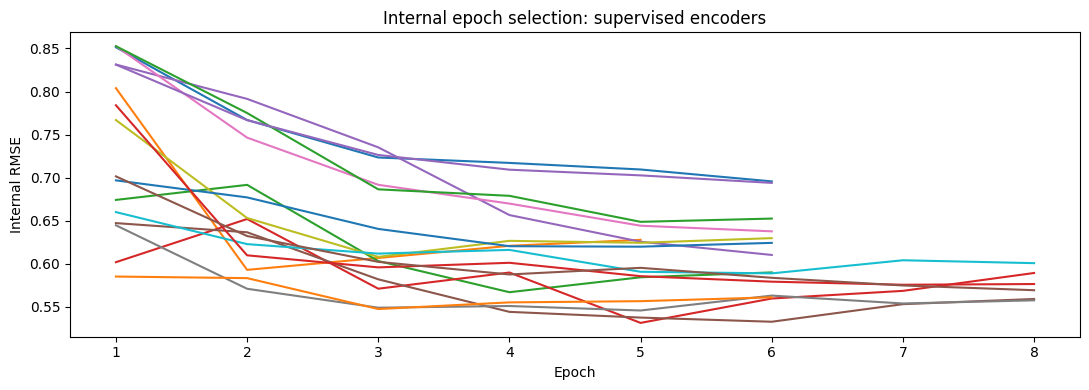

In [17]:
reference_names=[k for k in ['audio_ridge','text_ridge','fusion_ridge','fusion_rbf','residual','ordinal',
    'attention_rank','speaker_ridge','speaker_retrieval','catboost','deberta_finetuned'] if k in CANDIDATES]
reference_idx=[CANDIDATES.index(k) for k in reference_names]
reference_meta=fit_meta(production['oof'][:,reference_idx],y)
reference_oof=meta_predict(reference_meta,production['oof'][:,reference_idx])
reference_test=meta_predict(reference_meta,production['external'][:,reference_idx])
reference_metrics=metrics(y,reference_oof)
print('Reference-family OOF RMSE:',reference_metrics['rmse'])
print('Expanded V8 selected OOF RMSE:',oof_metrics['rmse'])
print('This is a same-run family comparison, not an exact replay of the 0.34 submission.')
fold_uncertainty=np.std(np.stack([meta_predict(final_meta,p) for p in production['fold_external']]),axis=0)
pd.DataFrame({'filename':test_df[TEST_FILE_COL],'prediction':test_prediction,
    'fold_disagreement':fold_uncertainty}).to_csv(WORK/'test_predictions_uncertainty_v8.csv',index=False)
# Gather actual epoch logs, preserving internal-vs-refit labels.
logs=[]
for path in MCACHE.rglob('history.json'):
    for row in json.loads(path.read_text()): logs.append(dict(run=str(path.parent.relative_to(MCACHE)),**row))
history_df=pd.DataFrame(logs); history_df.to_csv(WORK/'training_history_v8.csv',index=False)
fig,ax=plt.subplots(figsize=(11,4))
if not history_df.empty and 'internal_rmse' in history_df:
    for run,part in history_df.groupby('run'):
        if ('audio_tune' in run or 'text_tune' in run) and part.internal_rmse.notna().any():
            ax.plot(part.epoch,part.internal_rmse,label=run)
    ax.set(title='Internal epoch selection: supervised encoders',xlabel='Epoch',ylabel='Internal RMSE')
    if len(ax.lines)<=10: ax.legend(fontsize=7)
plt.tight_layout(); fig.savefig(WORK/'training_curves_v8.png',dpi=140); plt.show()


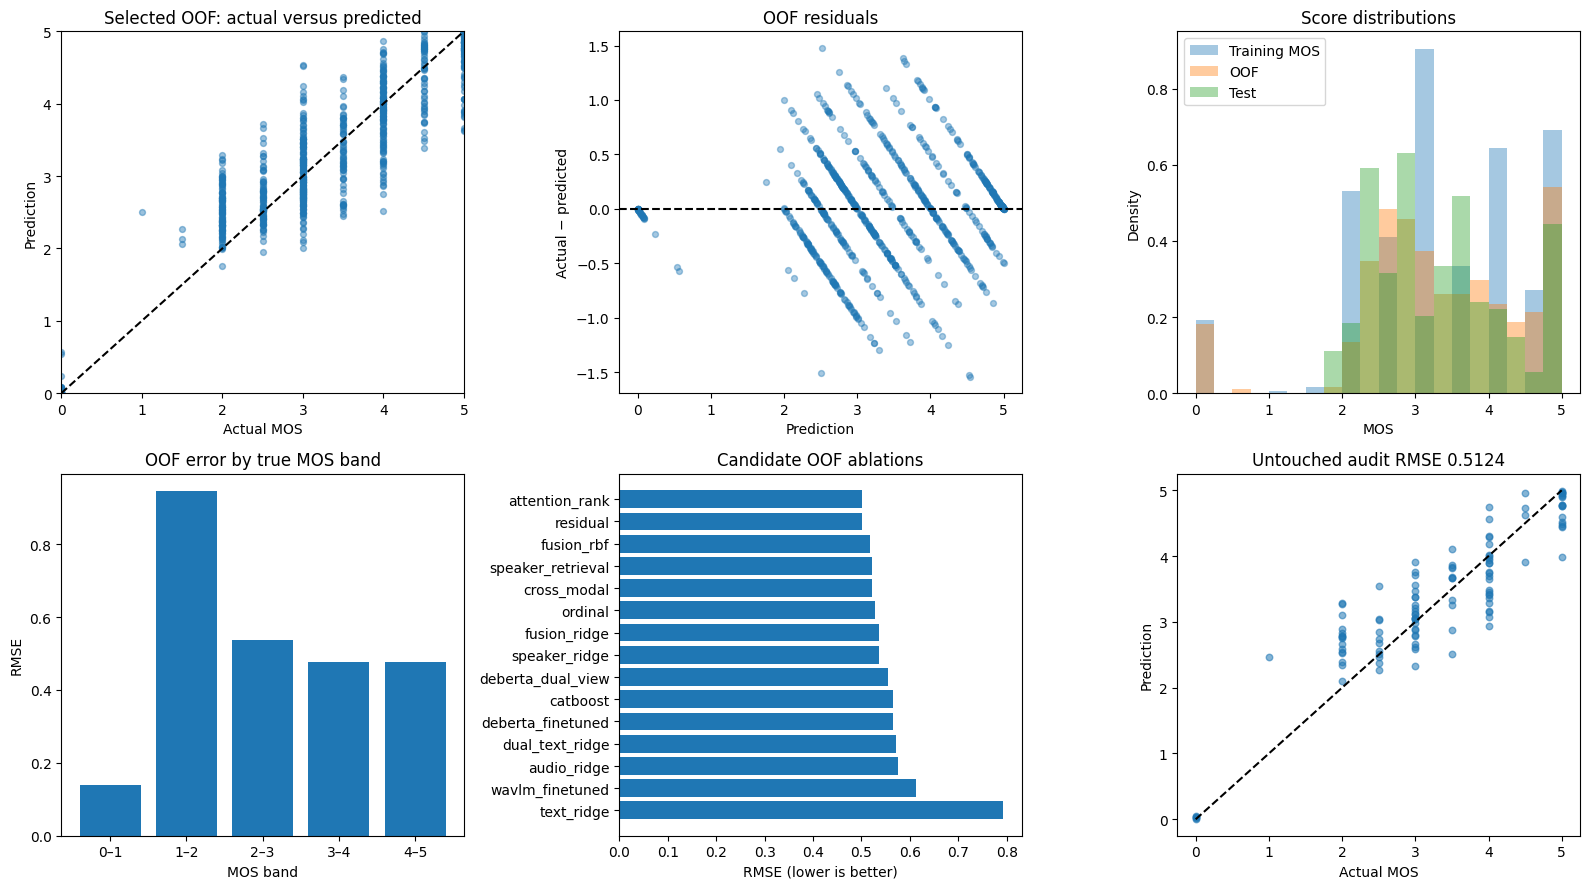

,band,n,rmse,mae,pearson,spearman
0,0–1,37,0.139785,0.062350,NaN,NaN
1,1–2,4,0.945809,0.867403,-0.889873,-0.774597
2,2–3,181,0.536052,0.428790,0.208135,0.191248
3,3–4,238,0.475676,0.377906,0.245107,0.243719
4,4–5,309,0.476311,0.345701,0.666104,0.687918


,filename,actual,prediction,absolute_error,transcript
698,audio_458.wav,3.0,4.539973,1.539973,I consider the best day of my life to be when ...
42,audio_769.wav,3.0,4.521510,1.521510,People in the market are selling fish in the m...
423,audio_108.wav,1.0,2.506303,1.506303,As a young child one of the most exciting plac...
465,audio_238.wav,4.0,2.520883,1.479117,The playground has many children. There are sl...
85,audio_240.wav,5.0,3.618453,1.381547,I have a short-term and long-term career goals...
724,audio_91.wav,5.0,3.643239,1.356761,"Imagine a vibrant marketplace in Vanilla, bust..."
606,audio_159.wav,5.0,3.669332,1.330668,okay I'm immersing in the melodic tranquility ...
534,audio_55.wav,2.0,3.291852,1.291852,"Well, what I can describe of a school playgrou..."
24,audio_269.wav,4.0,2.746049,1.253951,yeah my favorite hobby is doing long tennis. L...
578,audio_250.wav,3.0,4.245403,1.245403,I would never be this positive and optimistic ...


In [18]:
fig,axes=plt.subplots(2,3,figsize=(16,9))
axes[0,0].scatter(y,final_oof,alpha=.45,s=18); axes[0,0].plot([0,5],[0,5],'k--')
axes[0,0].set(title='Selected OOF: actual versus predicted',xlabel='Actual MOS',ylabel='Prediction',xlim=(0,5),ylim=(0,5))
axes[0,1].scatter(final_oof,y-final_oof,alpha=.4,s=18); axes[0,1].axhline(0,color='k',ls='--')
axes[0,1].set(title='OOF residuals',xlabel='Prediction',ylabel='Actual − predicted')
for values,name in [(y,'Training MOS'),(final_oof,'OOF'),(test_prediction,'Test')]:
    axes[0,2].hist(values,bins=np.linspace(0,5,21),alpha=.4,label=name,density=True)
axes[0,2].legend(); axes[0,2].set(title='Score distributions',xlabel='MOS',ylabel='Density')
rmse_rows=[]
for lo in range(5):
    mask=(y>=lo)&((y<lo+1) if lo<4 else (y<=5))
    if mask.any(): rmse_rows.append({'band':f'{lo}–{lo+1}','n':int(mask.sum()),**metrics(y[mask],final_oof[mask])})
band_report=pd.DataFrame(rmse_rows)
axes[1,0].bar(band_report['band'],band_report['rmse']); axes[1,0].set(title='OOF error by true MOS band',xlabel='MOS band',ylabel='RMSE')
ordered=results.sort_values('rmse',ascending=False)
axes[1,1].barh(ordered['model'],ordered['rmse']); axes[1,1].set(title='Candidate OOF ablations',xlabel='RMSE (lower is better)')
if audit_summary is not None:
    axes[1,2].scatter(y[audit_ids],audit_prediction,alpha=.55,s=22); axes[1,2].plot([0,5],[0,5],'k--')
    axes[1,2].set(title=f"Untouched audit RMSE {audit_summary['rmse']:.4f}",xlabel='Actual MOS',ylabel='Prediction')
else:
    axes[1,2].axis('off'); axes[1,2].text(.1,.5,'Audit was disabled',transform=axes[1,2].transAxes)
plt.tight_layout(); fig.savefig(WORK/'diagnostics_v8.png',dpi=150,bbox_inches='tight'); plt.show()
display(band_report); band_report.to_csv(WORK/'per_score_metrics_v8.csv',index=False)
error_df=pd.DataFrame({'filename':train_df[FILE_COL],'actual':y,'prediction':final_oof,
    'absolute_error':np.abs(y-final_oof),'transcript':text_list[:TRAIN_N]})
display(error_df.sort_values('absolute_error',ascending=False).head(12))


## 7. Submission schema and current test identities
The primary submission includes every current test ID in test.csv order. A compatible shorter supplied template is exported
separately by filename. An incompatible template is retained as ORIGINAL_SAMPLE_DF, and its column schema is reconstructed
with actual test IDs. The original-ID audit identifies unavailable IDs; no invented predictions are made for those IDs.
Always check the current Kaggle validator. Random test labels and template score placeholders are never supervision.


In [19]:
def build_submissions(test_frame,template,predictions,test_file_col,target_col,policy):
    if policy not in ['sample','test']: raise ValueError('SUBMISSION_POLICY must be sample or test.')
    predictions=clip(predictions)
    assert len(predictions)==len(test_frame) and np.isfinite(predictions).all()
    keys=[audio_key(x) for x in test_frame[test_file_col]]
    assert len(set(keys))==len(keys)
    lookup=dict(zip(keys,predictions))
    if template is not None:
        idcol=filename_column(template); scorecols=[c for c in template if c!=idcol]
        if len(scorecols)!=1: raise ValueError(f'Ambiguous sample schema: {list(template.columns)}')
        output_col=scorecols[0]; sample=template.copy()
        sample_keys=[audio_key(x) for x in sample[idcol]]
        assert len(set(sample_keys))==len(sample_keys) and set(sample_keys)<=set(keys)
        sample[output_col]=[lookup[k] for k in sample_keys]
        all_test=pd.DataFrame({idcol:test_frame[test_file_col].to_numpy(),output_col:predictions})
    else:
        output_col=target_col
        all_test=pd.DataFrame({test_file_col:test_frame[test_file_col].to_numpy(),output_col:predictions})
        sample=None
    primary=sample.copy() if policy=='sample' and sample is not None else all_test.copy()
    for frame in [primary,all_test]+([sample] if sample is not None else []):
        assert frame[output_col].between(0,5).all() and frame[output_col].notna().all()
    return primary,all_test,sample,output_col

primary,all_test,by_sample,OUTPUT_COL=build_submissions(test_df,sample_df,test_prediction,
    TEST_FILE_COL,LABEL_COL,CFG['SUBMISSION_POLICY'])
primary.to_csv(WORK/'submission.csv',index=False)
all_test.to_csv(WORK/'submission_all_test.csv',index=False)
if by_sample is not None: by_sample.to_csv(WORK/'submission_sample_format.csv',index=False)
# Re-read exactly the primary output: serialization, schema, range, IDs and order.
verified=pd.read_csv(WORK/'submission.csv')
assert list(verified.columns)==list(primary.columns) and len(verified)==len(primary)
idcol=filename_column(primary)
assert verified[idcol].astype(str).tolist()==primary[idcol].astype(str).tolist()
assert np.isfinite(verified[OUTPUT_COL]).all() and verified[OUTPUT_COL].between(0,5).all()
print('PRIMARY:',WORK/'submission.csv','| rows:',len(primary),'| policy:',CFG['SUBMISSION_POLICY'])
print('ALL TEST:',WORK/'submission_all_test.csv','| rows:',len(all_test))
if by_sample is not None: print('TEMPLATE:',WORK/'submission_sample_format.csv','| rows:',len(by_sample))
display(primary.head()); display(primary[OUTPUT_COL].describe())

reference_primary,_,_,_=build_submissions(test_df,sample_df,reference_test,TEST_FILE_COL,LABEL_COL,'test')
reference_primary.to_csv(WORK/'submission_reference_family_v8.csv',index=False)
if ORIGINAL_SAMPLE_DF is not None:
    sc=filename_column(ORIGINAL_SAMPLE_DF); prediction_col=[c for c in ORIGINAL_SAMPLE_DF if c!=sc][0]
    lookup=dict(zip([audio_key(v) for v in test_df[TEST_FILE_COL]],test_prediction))
    status=ORIGINAL_SAMPLE_DF[[sc]].copy()
    status['available_in_current_test']=[audio_key(v) in lookup for v in status[sc]]
    status['prediction_if_available']=[lookup.get(audio_key(v),np.nan) for v in status[sc]]
    status.to_csv(WORK/'original_template_id_audit_v8.csv',index=False)
    print('Original template ID coverage:',int(status.available_in_current_test.sum()),'/',len(status))


PRIMARY: /kaggle/working/submission.csv | rows: 216 | policy: test
ALL TEST: /kaggle/working/submission_all_test.csv | rows: 216
TEMPLATE: /kaggle/working/submission_sample_format.csv | rows: 216


,filename,label
0,audio_128.wav,3.138315
1,audio_156.wav,4.110959
2,audio_19.wav,4.873572
3,audio_108.wav,1.987346
4,audio_206.wav,2.346595


count    216.000000
mean       3.304987
std        0.861906
min        1.798434
25%        2.610137
50%        3.190205
75%        3.867136
max        4.977338
Name: label, dtype: float64

Original template ID coverage: 25 / 204


## 8. Assessment report and required training RMSE
The following cell displays the actual report after this run, including training RMSE, development OOF metrics and the
held-out audit. Keep these executed outputs in the notebook submitted to SHL. No historical public score is copied into
new training results, and the delivered unexecuted notebook has no measured V8 score.


## Save, verify and download outputs
The compact ZIP includes submissions, metrics, reports, plots, manifests, OOF predictions and training histories.
The optional full ZIP adds every V8 cache/checkpoint and feature artifact; it can be several GB. Finished learners retain
EMA/tunable weights and history; redundant optimizer-progress checkpoints are removed only after their complete weights
are saved. Frozen pretrained weights are referenced by immutable commit and downloaded again when reconstructing a model.
Both ZIPs have a file inventory and CRC validation. Repeated runs exclude the ZIP being written. On Kaggle, use the download
links or the Output/Files panel. No download link is claimed to start a browser download automatically.


In [20]:
audit_text=('Audit disabled; no held-out final-ensemble score.' if audit_summary is None else
    f"Held-out audit RMSE: **{audit_summary['rmse']:.6f}**; Pearson: **{audit_summary['pearson']}**; "
    f"{audit_summary['audit_n']} audit recordings. Descriptive group-bootstrap RMSE interval: {audit_summary['rmse_bootstrap_95pct']}.")
report=f"""# SHL 2026 — V8 assessment report

## Approach and preprocessing
Only train.csv provides labels. WAV recordings are decoded to mono 16 kHz; the full recording is covered by audio windows.
WavLM multi-layer statistics, a separate speaker encoder, acoustic/fluency features and CTC speech representations
provide complementary information. Whisper and CTC generate independent complete transcriptions. CTC overlap is trimmed
at frame level. Confidence, entropy, blank rate and transcript agreement expose ASR uncertainty. No grammatical correction
prompts or invented grammar annotations are used. Raw continuous MOS labels remain in [0,5].

## Pipeline architecture and training
V8 learns SHL MOS by fine-tuning the last {CFG['AUDIO_FT_UNFREEZE']} WavLM transformer blocks and last {CFG['FT_UNFREEZE']}
DeBERTa blocks. Frame/token attention, recording/chunk attention, learned positions, text-layer mixing and hierarchical
transformers support recording-level prediction. A separate cross-modal transformer reads audio, two text views and
fluency features. Existing residual, ordinal and ranking heads and tuned Ridge/Kernel Ridge/CatBoost baselines remain
candidates. A training-only confidence-gated retrieval candidate uses no filename or test label transfer.

Feature scaling, baseline tuning and epoch selection use only each fold's training data. Inner splits select epochs;
models then restart from the pretrained initialization and refit on the full outer training partition. Separate learning
rates, staged encoder warmup, accumulation, clipping, warmup/cosine scheduling and EMA stabilize training. Epoch checkpoints
store optimizer, scaler, RNG, EMA and history; completed learners retain compact tunable weights plus immutable model commits.

## Required training RMSE and evaluation
- **Training-data selected OOF RMSE (development diagnostic): {oof_metrics['rmse']:.6f}**
- **Training RMSE ({CFG['FINAL_FOLDS']}-fold ensemble, partly in-sample): {train_metrics['rmse']:.6f}**
- Selected OOF Pearson: {oof_metrics['pearson']}; MAE: {oof_metrics['mae']:.6f}; Spearman: {oof_metrics['spearman']}.
- {audit_text}
- Same-run reference-family OOF RMSE: {reference_metrics['rmse']:.6f}.

Ensemble weights and calibration are fitted on training OOF predictions; calibration selection: **{final_meta['kind']}**.
Selected OOF metrics are affected by stacking/calibration selection and are not a fully nested validation of stacking.
The held-out audit is excluded from all fitted choices for this recipe, scored once after those choices are fixed,
and then the unchanged procedure is refitted on all labels. It uses a smaller development training set. The partly
in-sample training RMSE is optimistic. Neither the reference-family result nor the OOF result replays the prior Kaggle
submission exactly. Your **reported V7 public score was 0.34**; V8 public/private scores and leaderboard rank are **unmeasured**.
The provided competition description mentions Pearson and RMSE without an exact custom formula.

## Interpretability
The notebook plots actual/predicted MOS, residuals, per-score errors, prediction distributions, candidate ablations,
internal epoch curves and the audit. High-error transcripts and ensemble weights are displayed. Fold disagreement is
reported as a diagnostic, not a calibrated confidence interval or causal explanation.

## Submission and reproducibility
Train rows: {TRAIN_N}; test rows: {TEST_N}; original supplied template rows: {ORIGINAL_SAMPLE_ROWS}.
Template status: **{TEMPLATE_STATUS}**. Primary submission rows: {len(primary)}, matched by normalized filename and clipped
to [0,5]. Incompatible template IDs are not assigned fabricated scores; a reconstructed schema uses current test IDs.
A separate ID audit records which original template IDs can be predicted. Submit the schema Kaggle currently accepts.
Feature key: {FEATURE_KEY}; training key: {TRAINING_KEY}; profile: {CFG['PROFILE']}; seed: {CFG['SEED']}.
Implementation SHA: {CFG['IMPLEMENTATION_SHA']}. Immutable pretrained commits: {MODEL_COMMITS}.
Runtime: Python {platform.python_version()}, Torch {torch.__version__}, Transformers {transformers.__version__},
scikit-learn {sklearn.__version__}, NumPy {np.__version__}.

## Limitations
Only {TRAIN_N} labeled recordings are available. Deeper learners can overfit, alternate ASR can be worse, and speaker/style
features may transfer poorly. Real group column: {group_col}; without real candidate IDs, exact-duplicate grouping does
not establish unseen-speaker accuracy. No target-distribution stretching, test-label tuning, pseudo-labeling or public-score
fitting is used. Larger models and more epochs do not guarantee a lower score. The full deep profile may exceed a single
Kaggle session; resume from preserved caches/checkpoints. Inference requires the pinned pretrained weights and fold artifacts.
"""
(WORK/'assessment_report_v8.md').write_text(report)
run_metrics={'training_oof_development':oof_metrics,'training_partly_in_sample':train_metrics,
    'held_out_audit':audit_summary,'reference_family_oof':reference_metrics,'calibration':final_meta['kind'],
    'weights':dict(zip(CANDIDATES,final_meta['weights'].tolist())),
    'submission_rows':len(primary),'test_rows':TEST_N,'original_template_rows':ORIGINAL_SAMPLE_ROWS,
    'template_status':TEMPLATE_STATUS,'configuration':CFG,'feature_key':FEATURE_KEY,'training_key':TRAINING_KEY,
    'reported_v7_public_score':.34,'v8_leaderboard_score':None}
atomic_json(WORK/'metrics_v8.json',run_metrics)
display(Markdown(report))
print('Primary submission:',WORK/'submission.csv')


# SHL 2026 — V8 assessment report

## Approach and preprocessing
Only train.csv provides labels. WAV recordings are decoded to mono 16 kHz; the full recording is covered by audio windows.
WavLM multi-layer statistics, a separate speaker encoder, acoustic/fluency features and CTC speech representations
provide complementary information. Whisper and CTC generate independent complete transcriptions. CTC overlap is trimmed
at frame level. Confidence, entropy, blank rate and transcript agreement expose ASR uncertainty. No grammatical correction
prompts or invented grammar annotations are used. Raw continuous MOS labels remain in [0,5].

## Pipeline architecture and training
V8 learns SHL MOS by fine-tuning the last 2 WavLM transformer blocks and last 4
DeBERTa blocks. Frame/token attention, recording/chunk attention, learned positions, text-layer mixing and hierarchical
transformers support recording-level prediction. A separate cross-modal transformer reads audio, two text views and
fluency features. Existing residual, ordinal and ranking heads and tuned Ridge/Kernel Ridge/CatBoost baselines remain
candidates. A training-only confidence-gated retrieval candidate uses no filename or test label transfer.

Feature scaling, baseline tuning and epoch selection use only each fold's training data. Inner splits select epochs;
models then restart from the pretrained initialization and refit on the full outer training partition. Separate learning
rates, staged encoder warmup, accumulation, clipping, warmup/cosine scheduling and EMA stabilize training. Epoch checkpoints
store optimizer, scaler, RNG, EMA and history; completed learners retain compact tunable weights plus immutable model commits.

## Required training RMSE and evaluation
- **Training-data selected OOF RMSE (development diagnostic): 0.484167**
- **Training RMSE (5-fold ensemble, partly in-sample): 0.217282**
- Selected OOF Pearson: 0.9204911564465872; MAE: 0.364305; Spearman: 0.883383055492771.
- Held-out audit RMSE: **0.512449**; Pearson: **0.9060288947661722**; 116 audit recordings. Descriptive group-bootstrap RMSE interval: [0.44425470912180337, 0.5782539761163651].
- Same-run reference-family OOF RMSE: 0.485934.

Ensemble weights and calibration are fitted on training OOF predictions; calibration selection: **raw**.
Selected OOF metrics are affected by stacking/calibration selection and are not a fully nested validation of stacking.
The held-out audit is excluded from all fitted choices for this recipe, scored once after those choices are fixed,
and then the unchanged procedure is refitted on all labels. It uses a smaller development training set. The partly
in-sample training RMSE is optimistic. Neither the reference-family result nor the OOF result replays the prior Kaggle
submission exactly. Your **reported V7 public score was 0.34**; V8 public/private scores and leaderboard rank are **unmeasured**.
The provided competition description mentions Pearson and RMSE without an exact custom formula.

## Interpretability
The notebook plots actual/predicted MOS, residuals, per-score errors, prediction distributions, candidate ablations,
internal epoch curves and the audit. High-error transcripts and ensemble weights are displayed. Fold disagreement is
reported as a diagnostic, not a calibrated confidence interval or causal explanation.

## Submission and reproducibility
Train rows: 769; test rows: 216; original supplied template rows: 204.
Template status: **incompatible IDs; schema reconstructed from test.csv**. Primary submission rows: 216, matched by normalized filename and clipped
to [0,5]. Incompatible template IDs are not assigned fabricated scores; a reconstructed schema uses current test IDs.
A separate ID audit records which original template IDs can be predicted. Submit the schema Kaggle currently accepts.
Feature key: 8f156ae3551657ca; training key: f2e67ed5d8d81480; profile: deep; seed: 42.
Implementation SHA: de9a837b4f872dbe1c3527eca1f650aeddf0b9ed524c770adb355aa67fa863c2. Immutable pretrained commits: {'microsoft/wavlm-base-plus': '4c66d4806a428f2e922ccfa1a962776e232d487b', 'openai/whisper-large-v3-turbo': '41f01f3fe87f28c78e2fbf8b568835947dd65ed9', 'microsoft/deberta-v3-base': '8ccc9b6f36199bec6961081d44eb72fb3f7353f3', 'microsoft/wavlm-base-plus-sv': 'feb593a6c23c1cc3d9510425c29b0a14d2b07b1e', 'facebook/wav2vec2-large-960h-lv60-self': '54074b1c16f4de6a5ad59affb4caa8f2ea03a119'}.
Runtime: Python 3.13.15, Torch 2.11.0+cu128, Transformers 4.57.1,
scikit-learn 1.6.1, NumPy 2.1.3.

## Limitations
Only 769 labeled recordings are available. Deeper learners can overfit, alternate ASR can be worse, and speaker/style
features may transfer poorly. Real group column: None; without real candidate IDs, exact-duplicate grouping does
not establish unseen-speaker accuracy. No target-distribution stretching, test-label tuning, pseudo-labeling or public-score
fitting is used. Larger models and more epochs do not guarantee a lower score. The full deep profile may exceed a single
Kaggle session; resume from preserved caches/checkpoints. Inference requires the pinned pretrained weights and fold artifacts.


Primary submission: /kaggle/working/submission.csv


In [21]:
from IPython.display import FileLink
files=[p for p in WORK.iterdir() if p.is_file() and p.name not in ['results_inventory_v8.json','artifacts_inventory_v8.json'] and (p.name.endswith('_v8.csv') or p.name.endswith('_v8.json')
    or p.name.endswith('_v8.md') or p.name.endswith('_v8.png') or p.name in ['submission.csv','submission_all_test.csv','submission_sample_format.csv'])]
compact=[p for p in files if p.suffix not in ['.npz','.pt','.joblib']]
atomic_json(WORK/'results_inventory_v8.json',[{'path':p.name,'bytes':p.stat().st_size,'sha256':file_sha(p)} for p in sorted(compact)])
compact.append(WORK/'results_inventory_v8.json')
def package_zip(destination,paths):
    destination=Path(destination); temporary=Path(str(destination)+'.partial')
    unique=sorted({p.resolve() for p in paths if p.is_file() and p.resolve() not in [destination.resolve(),temporary.resolve()]})
    with zipfile.ZipFile(temporary,'w',compression=zipfile.ZIP_DEFLATED,compresslevel=1,allowZip64=True) as z:
        for p in tqdm(unique,desc='ZIP '+destination.name,unit='file'): z.write(p,str(p.relative_to(WORK.resolve())))
    with zipfile.ZipFile(temporary) as z:
        bad=z.testzip()
        if bad is not None: raise RuntimeError('ZIP CRC check failed: '+bad)
    temporary.replace(destination)
    print(destination.name,'|',len(unique),'files |',round(destination.stat().st_size/1024**2,1),'MB')
    display(FileLink(os.path.relpath(destination,Path.cwd())))
package_zip(WORK/'SHL_V8_Results.zip',compact)
if CFG['ZIP_ALL_ARTIFACTS']:
    full=[p for p in CACHE.rglob('*') if p.is_file() and not p.name.endswith('.tmp')]
    full += [p for p in WORK.iterdir() if p.is_file() and (p.name.endswith('_v8.npz') or p.name.endswith('_v8.joblib'))]
    full+=compact
    atomic_json(WORK/'artifacts_inventory_v8.json',[{'path':str(p.relative_to(WORK)),'bytes':p.stat().st_size} for p in sorted(set(full))])
    full.append(WORK/'artifacts_inventory_v8.json')
    package_zip(WORK/'SHL_V8_All_Artifacts.zip',full)
print('On Kaggle, download ZIPs from these links or the Output / Files panel.')


ZIP SHL_V8_Results.zip:   0%|          | 0/25 [00:00<?, ?file/s]

SHL_V8_Results.zip | 25 files | 1.4 MB


/kaggle/working/SHL_V8_Results.zip

ZIP SHL_V8_All_Artifacts.zip:   0%|          | 0/6341 [00:00<?, ?file/s]

SHL_V8_All_Artifacts.zip | 6341 files | 2957.9 MB


/kaggle/working/SHL_V8_All_Artifacts.zip

On Kaggle, download ZIPs from these links or the Output / Files panel.


## Official implementation references
- [SHL competition](https://www.kaggle.com/competitions/shl-hiring-assessment-2026): the supplied task and rubric govern the assessment.
- [WavLM](https://huggingface.co/microsoft/wavlm-base-plus), [speaker verification](https://huggingface.co/microsoft/wavlm-base-plus-sv), and [WavLM API](https://huggingface.co/docs/transformers/v4.57.1/model_doc/wavlm).
- [Whisper turbo](https://huggingface.co/openai/whisper-large-v3-turbo) and [Whisper generation](https://huggingface.co/docs/transformers/v4.57.1/model_doc/whisper).
- [CTC recognizer](https://huggingface.co/facebook/wav2vec2-large-960h-lv60-self) and [DeBERTa](https://huggingface.co/microsoft/deberta-v3-base).
- [PyTorch EMA/SWA](https://docs.pytorch.org/docs/stable/generated/torch.optim.swa_utils.AveragedModel.html) and [validation guidance](https://scikit-learn.org/stable/modules/cross_validation.html).

V8 was structurally and synthetically exercised during preparation. Actual SHL training, leaderboard evaluation and new RMSE
results require running this notebook on the supplied competition audio. The prior 0.34 public score is user-reported.
